# Bluestock Mutual Fund — Advanced Analytics

**Notebook:** `05_advanced_analytics.ipynb`  ·  **Stage:** Day 6 (Advanced Analytics)

This notebook layers tail-risk and advanced portfolio analytics on top of the daily returns built in
Day 4. Each section follows the same flow — **load → compute → validate → analyse & visualise →
insight** — and every chart is exported to `reports/charts/`.

## Contents
1. [Historical VaR & CVaR Analysis](#1.-Historical-VaR-&-CVaR-Analysis)
2. [Rolling 90-Day Sharpe Ratio Analysis](#2.-Rolling-90-Day-Sharpe-Ratio-Analysis)
3. [Investor Cohort Analysis](#3.-Investor-Cohort-Analysis)
4. [SIP Continuation Analysis](#4.-SIP-Continuation-Analysis)
5. [Fund Recommendation Engine](#5.-Fund-Recommendation-Engine)
6. [Sector Concentration Risk (HHI Analysis)](#6.-Sector-Concentration-Risk-(HHI-Analysis))
7. [Advanced Analytics Executive Summary](#7.-Advanced-Analytics-Executive-Summary)

In [1]:
# === Setup: imports, paths, and shared styling (run once) ===
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Project paths (resolve repo root whether run from /notebooks or the repo root) ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"
CHARTS_DIR = PROJECT_ROOT / "reports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Shared chart styling ---
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"]

print(f"Project root  : {PROJECT_ROOT}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Raw dir       : {RAW_DIR}")
print(f"Charts dir    : {CHARTS_DIR}")

Project root  : /Users/dheerajreddy/bluestock_mf_capstone
Processed dir : /Users/dheerajreddy/bluestock_mf_capstone/data/processed
Raw dir       : /Users/dheerajreddy/bluestock_mf_capstone/data/raw
Charts dir    : /Users/dheerajreddy/bluestock_mf_capstone/reports/charts


## 1. Historical VaR & CVaR Analysis

**Value at Risk (VaR)** answers a single question: *on a bad day, how much can this fund lose?* The
**historical** method makes no distributional assumption — it simply reads the loss off the empirical
distribution of realised daily returns. At the 95% confidence level:

$$\text{VaR}_{95} = \text{5th percentile of daily returns}$$

So VaR$_{95}$ is the return such that only 5% of days were worse. It is a *threshold* — it says nothing
about **how bad** the worst 5% actually were. That gap is filled by **Conditional VaR (CVaR)**, also
called *Expected Shortfall* — the average loss on the days that breached VaR:

$$\text{CVaR}_{95} = \text{mean of all daily returns} \le \text{VaR}_{95}$$

Because CVaR averages the deep tail, it is always **at least as negative as VaR** ($\text{CVaR} \le
\text{VaR}$), and the gap between them measures how *fat* the loss tail is. We compute both per fund,
rank funds by tail severity (most-negative CVaR = highest risk = `risk_rank` 1), and export the report.

### 1.1 Load datasets

Load the daily returns built in Day 4 (`daily_returns.csv`) and the fund master (`01_fund_master.csv`)
for `scheme_name` and `category`. The leading per-scheme `NaN` (first day has no prior NAV) carries
through from Day 4 and is dropped before any percentile is taken.

In [2]:
# Daily returns (one row per scheme per trading day) + fund metadata
returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(RAW_DIR / "01_fund_master.csv")

n_funds = returns_df["amfi_code"].nunique()
print(f"Daily returns : {len(returns_df):,} rows  ·  {n_funds} schemes")
print(f"Date span     : {returns_df['date'].min().date()} -> {returns_df['date'].max().date()}")
print(f"Leading NaNs  : {returns_df['daily_return'].isna().sum()} (one per scheme, dropped below)")
print(f"Fund master   : {len(master)} schemes  ·  categories {master['category'].value_counts().to_dict()}")

Daily returns : 64,320 rows  ·  40 schemes
Date span     : 2022-01-03 -> 2026-05-29
Leading NaNs  : 40 (one per scheme, dropped below)
Fund master   : 40 schemes  ·  categories {'Equity': 34, 'Debt': 6}


### 1.2 Compute VaR & CVaR per fund

For each scheme we drop the leading `NaN`, take the **5th percentile** of daily returns as VaR$_{95}$
(`np.percentile` with linear interpolation), then average every return at or below that threshold to get
CVaR$_{95}$. `n_obs` records how many daily returns fed each estimate — a transparency check that all
funds share the same history depth.

In [3]:
def var_cvar_95(returns: pd.Series) -> pd.Series:
    """Historical VaR & CVaR at 95% for one scheme's daily returns."""
    r = returns.dropna()
    var_95 = np.percentile(r, 5)                 # 5th percentile (threshold loss)
    cvar_95 = r[r <= var_95].mean()              # mean loss in the breached tail
    return pd.Series({"var_95": var_95, "cvar_95": cvar_95, "n_obs": int(r.size)})

risk_raw = (
    returns_df.groupby("amfi_code")["daily_return"]
    .apply(var_cvar_95)
    .unstack()
    .reset_index()
)
risk_raw["n_obs"] = risk_raw["n_obs"].astype(int)

print(f"Computed VaR/CVaR for {len(risk_raw)} schemes")
print(f"Observations per fund: {sorted(risk_raw['n_obs'].unique())}")
print(f"VaR_95  range: {risk_raw['var_95'].min()*100:6.2f}%  to  {risk_raw['var_95'].max()*100:6.2f}%")
print(f"CVaR_95 range: {risk_raw['cvar_95'].min()*100:6.2f}%  to  {risk_raw['cvar_95'].max()*100:6.2f}%")

Computed VaR/CVaR for 40 schemes
Observations per fund: [np.int64(1607)]
VaR_95  range:  -2.39%  to   -0.02%
CVaR_95 range:  -3.03%  to   -0.03%


### 1.3 Build the risk-ranking table

Merge `scheme_name` and `category` from the master, then rank by tail severity. The riskiest fund —
the **most negative CVaR** — gets `risk_rank` 1. `method="first"` breaks any ties deterministically so
ranks stay unique. Required output columns, in order: `amfi_code · scheme_name · category · var_95 ·
cvar_95 · risk_rank`.

In [4]:
var_cvar_report = risk_raw.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)
# risk_rank 1 = highest risk = most negative (smallest) CVaR
var_cvar_report["risk_rank"] = (
    var_cvar_report["cvar_95"].rank(ascending=True, method="first").astype(int)
)

var_cvar_report = var_cvar_report.sort_values("risk_rank")[[
    "amfi_code", "scheme_name", "category", "var_95", "cvar_95", "risk_rank",
]].reset_index(drop=True)

# Readable view (percentages); stored file keeps raw decimals
view = var_cvar_report.copy()
view["var_95"] = (view["var_95"] * 100).round(3)
view["cvar_95"] = (view["cvar_95"] * 100).round(3)
print("Top 10 riskiest funds (VaR/CVaR shown as %):")
view.head(10)

Top 10 riskiest funds (VaR/CVaR shown as %):


,amfi_code,scheme_name,category,var_95,cvar_95,risk_rank
0,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-2.391,-3.029,1
1,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.316,-3.016,2
2,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.281,-2.994,3
3,119095,Axis Small Cap Fund - Regular - Growth,Equity,-2.328,-2.969,4
4,149324,DSP Small Cap Fund - Regular - Growth,Equity,-2.152,-2.857,5
5,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.150,-2.844,6
6,119094,Axis Midcap Fund - Regular - Growth,Equity,-1.700,-2.237,7
7,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,-1.622,-2.236,8
8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,-1.690,-2.185,9
9,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-1.686,-2.177,10


### 1.4 Validate

1. **Coverage** — exactly **40 funds**, one row per scheme, merge introduced no nulls.
2. **No missing values** — every `var_95` and `cvar_95` is populated.
3. **Tail ordering** — `cvar_95 ≤ var_95` for *every* fund (CVaR averages the tail beyond VaR, so it
   can never be less negative).
4. **Rank integrity** — `risk_rank` is a clean, unique `1..40`.

In [5]:
n = len(var_cvar_report)

# 1) Coverage
assert n == 40, f"Expected 40 funds, got {n}"
assert var_cvar_report["amfi_code"].is_unique, "amfi_code must be unique"
print(f"Coverage: {n} funds, one row each — OK")

# 2) No missing values
missing = var_cvar_report.isna().sum().sum()
assert missing == 0, f"Found {missing} missing values"
print(f"Missing values: {missing} — OK")

# 3) CVaR <= VaR for every fund
breaches = var_cvar_report[var_cvar_report["cvar_95"] > var_cvar_report["var_95"]]
assert breaches.empty, f"{len(breaches)} funds violate CVaR <= VaR"
worst_gap = (var_cvar_report["var_95"] - var_cvar_report["cvar_95"]).max()
print(f"CVaR <= VaR for all {n} funds — OK  (largest VaR->CVaR gap: {worst_gap*100:.3f} pts)")

# 4) Rank integrity
ranks = sorted(var_cvar_report["risk_rank"].tolist())
assert var_cvar_report["risk_rank"].is_unique, "Ranks must be unique"
assert ranks == list(range(1, n + 1)), "Ranks must be a clean 1..N"
print(f"risk_rank is a unique 1..{n} — OK")

print("\nAll VaR/CVaR validations passed.")

Coverage: 40 funds, one row each — OK
Missing values: 0 — OK
CVaR <= VaR for all 40 funds — OK  (largest VaR->CVaR gap: 0.713 pts)
risk_rank is a unique 1..40 — OK

All VaR/CVaR validations passed.


### 1.5 Save the report

Persist raw decimal VaR/CVaR (not percentages) to `data/processed/var_cvar_report.csv`, then reload to
confirm the schema and row count survive the round trip.

In [6]:
VAR_CVAR_PATH = PROCESSED_DIR / "var_cvar_report.csv"
var_cvar_report.to_csv(VAR_CVAR_PATH, index=False)
print(f"Saved {len(var_cvar_report)} schemes -> {VAR_CVAR_PATH}")

reloaded = pd.read_csv(VAR_CVAR_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded)}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 40 schemes -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/var_cvar_report.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'var_95', 'cvar_95', 'risk_rank']
Reloaded rows: 40  ·  missing: 0


### 1.6 Top 15 riskiest funds — VaR vs CVaR

Horizontal bars show **CVaR$_{95}$** (the average tail loss) for the 15 highest-risk funds; a marker on
each bar flags **VaR$_{95}$** (the threshold). The space between the marker and the bar end is the *tail
extension* — how much deeper the average bad day runs beyond the 5%-worst threshold. Bars are coloured
by category.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/var_cvar_risk_rankings.png

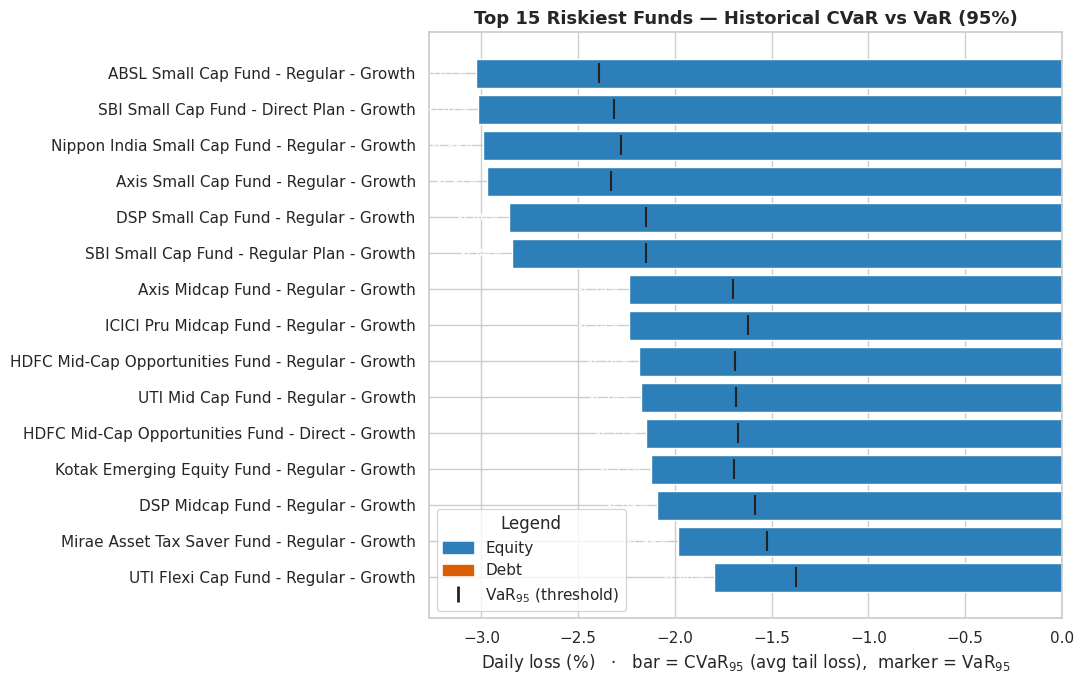

In [7]:
top15 = var_cvar_report.nsmallest(15, "cvar_95").iloc[::-1]   # riskiest at top of chart
cat_colors = {"Equity": "#2c7fb8", "Debt": "#d95f02"}
colors = top15["category"].map(cat_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15["scheme_name"], top15["cvar_95"] * 100, color=colors)

# VaR marker (threshold) on each bar, plus CVaR label at the bar end
ax.scatter(top15["var_95"] * 100, range(len(top15)),
           marker="|", s=220, color="#222222", zorder=3, label="VaR$_{95}$ (threshold)")
for y, (cv, vv) in enumerate(zip(top15["cvar_95"] * 100, top15["var_95"] * 100)):
    ax.text(cv - 0.05, y, f"{cv:.2f}%", va="center", ha="right", fontsize=8.5, color="white")

ax.set_title("Top 15 Riskiest Funds — Historical CVaR vs VaR (95%)", fontsize=13, weight="bold")
ax.set_xlabel("Daily loss (%)   ·   bar = CVaR$_{95}$ (avg tail loss),  marker = VaR$_{95}$")
ax.margins(x=0.08)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_colors.values()]
handles.append(plt.Line2D([0], [0], marker="|", color="#222222", linestyle="None",
                          markersize=12, markeredgewidth=2))
ax.legend(handles, list(cat_colors.keys()) + ["VaR$_{95}$ (threshold)"],
          title="Legend", loc="lower left")
plt.tight_layout()

VAR_CHART_PATH = CHARTS_DIR / "var_cvar_risk_rankings.png"
fig.savefig(VAR_CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {VAR_CHART_PATH}")
plt.show()

### 1.7 Insights

*All figures are the actual values computed above (40 schemes, 1,607 daily returns each, 2022-01-03 →
2026-05-29). VaR/CVaR are **daily** losses at the 95% level.*

**The tail-risk spectrum is enormous — about 90× wide.** Daily VaR$_{95}$ ranges from **−2.39%** at the
risky end to **−0.02%** at the safe end; CVaR$_{95}$ runs from **−3.03%** to **−0.03%**. In plain terms:
on a 1-in-20 bad day the riskiest fund loses roughly **2.4%**, and *when* that day arrives the average
loss is **3.0%** — while the safest fund barely registers a **0.03%** average tail loss.

**Small- and mid-cap equity owns the entire deep tail.** The **10 riskiest funds are all equity** — the
**6 small-cap** funds take ranks **1–6**, followed by **4 mid-cap** funds at **7–10**. The single
riskiest is **ABSL Small Cap Fund (Regular)** with VaR$_{95}$ **−2.39%** and CVaR$_{95}$ **−3.03%**,
just ahead of **SBI Small Cap (Direct)** (CVaR **−3.02%**) and **Nippon India Small Cap** (**−2.99%**).
This mirrors the Day 4 drawdown findings — the same funds that deliver the highest long-run returns are
the ones that punish investors hardest on bad days.

**Liquid debt funds are a different asset class entirely.** The three safest funds are all **liquid**:
**ICICI Pru Liquid** (rank 40, VaR **−0.02%**, CVaR **−0.03%**), **Kotak Liquid** (39) and **ABSL
Liquid** (38). Across categories the averages are stark — **Equity averages VaR −1.52% / CVaR −1.99%**
versus **Debt VaR −0.18% / CVaR −0.25%**, an order-of-magnitude difference in daily tail risk. Note
that "debt" is not monolithic: the gilt and short-duration debt funds (VaR ≈ −0.33%) sit well above the
near-zero liquid funds, so duration, not just the equity/debt label, drives tail risk.

**CVaR adds real information beyond VaR.** On average CVaR$_{95}$ is **1.34× as deep as VaR$_{95}$** —
i.e. once a loss breaches the 5% threshold, it overshoots by about a third on average. A VaR-only view
therefore *understates* how bad the genuinely bad days are; this tail-fatness is exactly why CVaR (not
VaR) is used here to rank risk.

**Implications for investors.**
- **Match the fund to the stomach.** A small-cap investor should expect ~1-in-20 days near **−2.4%**
  and tail averages near **−3%** — fine for a long horizon, painful for short-term money.
- **Use liquid funds as the genuine cash-equivalent sleeve** (≈ −0.03% tail), with gilt/short-duration
  debt as a middle ground when a little yield is worth a modestly fatter tail.
- **Read CVaR, not just VaR.** The 34% average overshoot means the threshold alone undersells the
  downside; CVaR is the honest number for sizing worst-case exposure.

**Data note.** Historical VaR/CVaR are **backward-looking** — they describe the 2022–2026 window only
and assume the loss distribution is representative of the future, which it may not be. Estimates use the
same **1,607** daily returns for every fund, so cross-fund comparison is apples-to-apples; the
forward-filled NAV days from Day 4 can flatten a few returns to exactly 0, which mildly *understates*
tail magnitudes rather than inflating them.

## 2. Rolling 90-Day Sharpe Ratio Analysis

Section 3 of Day 4 computed each fund's Sharpe ratio over the *whole* history — a single number. But
risk-adjusted performance is not static: a fund can earn its Sharpe in a calm year and give it back in a
crash. A **rolling Sharpe** re-computes the ratio inside a moving window so we can watch risk-adjusted
performance *evolve through time*.

For a 90-trading-day window (≈ one calendar quarter):

$$\text{rolling\_sharpe}_t = \frac{\text{mean}(r_{t-89:t})}{\text{std}(r_{t-89:t})}\times\sqrt{252}$$

**Risk-free rate = 0.** We deliberately set $r_f = 0$ for the rolling series. The window is short (a
quarter), the daily risk-free drag is tiny relative to the window's noise, and a zero baseline keeps the
*shape* of the series — its peaks, troughs and stability — driven purely by the fund's own
return/volatility dynamics rather than by an assumed cash rate. The $\sqrt{252}$ factor annualises the
daily ratio. (Day 4's whole-period Sharpe is unaffected; this is a separate, time-resolved lens.)

We track **5 representative funds** spanning the risk spectrum — from a liquid fund to a small-cap — so
the contrast in Sharpe *stability* is visible.

### 2.1 Load datasets and select the 5 funds

Load `daily_returns.csv` and `01_fund_master.csv`. The brief names 5 funds; the table below documents
the exact scheme each maps to in our universe. All five resolve to **Regular – Growth** plans (kept
consistent across funds), and each requested name had an unambiguous match.

| Requested | Matched scheme | `amfi_code` | sub-category |
|---|---|---|---|
| Mirae Asset Large Cap | Mirae Asset Large Cap Fund - Regular - Growth | 148567 | Large Cap |
| Axis Midcap | Axis Midcap Fund - Regular - Growth | 119094 | Mid Cap |
| SBI Small Cap | SBI Small Cap Fund - Regular Plan - Growth | 119598 | Small Cap |
| ICICI Prudential Liquid | ICICI Pru Liquid Fund - Regular - Growth | 120507 | Liquid |
| UTI Nifty 50 Index | UTI Nifty 50 Index Fund - Regular - Growth | 102885 | Index |

In [8]:
returns_df = pd.read_csv(PROCESSED_DIR / "daily_returns.csv", parse_dates=["date"])
master = pd.read_csv(RAW_DIR / "01_fund_master.csv")

# Requested fund -> resolved amfi_code (documented above)
SELECTED = {
    148567: "Mirae Asset Large Cap",
    119094: "Axis Midcap",
    119598: "SBI Small Cap",
    120507: "ICICI Pru Liquid",
    102885: "UTI Nifty 50 Index",
}
WINDOW = 90              # trading days (~1 quarter)
TRADING_DAYS = 252      # annualisation factor
RISK_FREE = 0.0         # documented choice for the rolling series

# Confirm every selected code exists and pull its full scheme name
lookup = master.set_index("amfi_code")["scheme_name"]
for code in SELECTED:
    assert code in lookup.index, f"amfi_code {code} not found in master"
    print(f"{SELECTED[code]:24s} -> {code}  {lookup[code]}")
print(f"\nSelected {len(SELECTED)} funds  ·  window = {WINDOW}d  ·  rf = {RISK_FREE}  ·  annualise x sqrt({TRADING_DAYS})")

Mirae Asset Large Cap    -> 148567  Mirae Asset Large Cap Fund - Regular - Growth
Axis Midcap              -> 119094  Axis Midcap Fund - Regular - Growth
SBI Small Cap            -> 119598  SBI Small Cap Fund - Regular Plan - Growth
ICICI Pru Liquid         -> 120507  ICICI Pru Liquid Fund - Regular - Growth
UTI Nifty 50 Index       -> 102885  UTI Nifty 50 Index Fund - Regular - Growth

Selected 5 funds  ·  window = 90d  ·  rf = 0.0  ·  annualise x sqrt(252)


### 2.2 Compute the rolling 90-day Sharpe per fund

For each fund we sort by date, take the 90-day rolling mean and std of daily returns, and form the
annualised ratio. The first 89 windows are incomplete so `rolling(90)` returns `NaN` there (plus the one
leading `NaN` from the return calculation) — the first *real* Sharpe therefore appears on the 90th
available return. We keep the full per-date series for the chart and a clean (`dropna`) series for the
statistics.

In [9]:
def rolling_sharpe(returns: pd.Series, window=WINDOW, periods=TRADING_DAYS) -> pd.Series:
    """Annualised rolling Sharpe (rf = 0) over `window` trading days."""
    rmean = returns.rolling(window).mean()
    rstd = returns.rolling(window).std()
    return (rmean / rstd) * np.sqrt(periods)

series = {}   # short name -> DataFrame[date, sharpe] (rows where sharpe is defined)
for code, short in SELECTED.items():
    fund = returns_df[returns_df["amfi_code"] == code].sort_values("date").copy()
    fund["rolling_sharpe"] = rolling_sharpe(fund["daily_return"])
    defined = fund.dropna(subset=["rolling_sharpe"])[["date", "rolling_sharpe"]].reset_index(drop=True)
    series[short] = defined
    print(f"{short:24s} {len(defined):4d} rolling values  ·  "
          f"{defined['date'].min().date()} -> {defined['date'].max().date()}")

Mirae Asset Large Cap    1518 rolling values  ·  2022-04-03 -> 2026-05-29
Axis Midcap              1518 rolling values  ·  2022-04-03 -> 2026-05-29
SBI Small Cap            1518 rolling values  ·  2022-04-03 -> 2026-05-29
ICICI Pru Liquid         1518 rolling values  ·  2022-04-03 -> 2026-05-29
UTI Nifty 50 Index       1518 rolling values  ·  2022-04-03 -> 2026-05-29


### 2.3 Build the summary table

One row per fund with the **latest**, **average**, **min** and **max** rolling Sharpe over its defined
window. Required columns: `scheme_name · latest_rolling_sharpe · average_rolling_sharpe ·
min_rolling_sharpe · max_rolling_sharpe`. We also carry the rolling **std of the Sharpe series itself**
(`sharpe_volatility`) — the direct measure of how much risk-adjusted performance swings through time,
used in the stability comparison below.

In [10]:
records = []
for short, df in series.items():
    s = df["rolling_sharpe"]
    records.append({
        "scheme_name": short,
        "latest_rolling_sharpe": s.iloc[-1],
        "average_rolling_sharpe": s.mean(),
        "min_rolling_sharpe": s.min(),
        "max_rolling_sharpe": s.max(),
        "sharpe_volatility": s.std(),          # stdev of the Sharpe series (time-stability)
    })

rolling_sharpe_summary = (
    pd.DataFrame(records)
    .sort_values("average_rolling_sharpe", ascending=False)
    .reset_index(drop=True)
)
rolling_sharpe_summary.round(3)

,scheme_name,latest_rolling_sharpe,average_rolling_sharpe,min_rolling_sharpe,max_rolling_sharpe,sharpe_volatility
0,ICICI Pru Liquid,12.492,10.402,7.362,13.718,1.259
1,Mirae Asset Large Cap,0.761,1.607,-2.734,7.343,1.636
2,UTI Nifty 50 Index,1.040,1.179,-2.006,3.933,1.109
3,Axis Midcap,0.082,1.122,-3.309,4.288,1.461
4,SBI Small Cap,2.368,0.849,-3.282,5.872,1.685


### 2.4 Validate

1. **Window depth** — each fund has **≥ 90 observations** before its first Sharpe (the first 89 windows
   are `NaN`).
2. **No divide-by-zero** — every 90-day rolling std is strictly positive.
3. **No infinite / NaN values** — the defined Sharpe series is all finite.
4. **Date ranges** — each fund's rolling window starts ~90 trading days after its first return and ends
   on the last trading day; all five share the same span.
5. **Exactly 5 funds** analysed.

In [11]:
n_funds = len(series)

# 5) Exactly 5 funds
assert n_funds == 5, f"Expected 5 funds, got {n_funds}"
print(f"Funds analysed: {n_funds} — OK")

for short, code in zip(series, SELECTED.values()):
    pass  # (names already validated against master in 2.1)

for code, short in SELECTED.items():
    fund = returns_df[returns_df["amfi_code"] == code].sort_values("date")
    ret = fund["daily_return"]
    rstd = ret.rolling(WINDOW).std()
    rsharpe = series[short]["rolling_sharpe"]

    # 1) Window depth: at least 90 returns exist before the first defined Sharpe
    n_returns = ret.notna().sum()
    assert n_returns >= WINDOW, f"{short}: only {n_returns} returns (<{WINDOW})"

    # 2) No divide-by-zero: every completed rolling std is > 0
    completed_std = rstd.dropna()
    assert (completed_std > 0).all(), f"{short}: zero rolling std (divide-by-zero)"

    # 3) No infinite / NaN in the defined series
    assert np.isfinite(rsharpe).all(), f"{short}: non-finite rolling Sharpe"

    print(f"{short:24s} returns={n_returns:4d}  min_roll_std={completed_std.min():.2e}  "
          f"finite={np.isfinite(rsharpe).all()}")

# 4) Date ranges
spans = {s: (df['date'].min(), df['date'].max()) for s, df in series.items()}
starts = {v[0] for v in spans.values()}; ends = {v[1] for v in spans.values()}
print(f"\nShared rolling window: {min(starts).date()} -> {max(ends).date()}  "
      f"(aligned start={len(starts)==1}, aligned end={len(ends)==1})")
print("\nAll rolling-Sharpe validations passed.")

Funds analysed: 5 — OK
Mirae Asset Large Cap    returns=1607  min_roll_std=6.01e-03  finite=True
Axis Midcap              returns=1607  min_roll_std=8.13e-03  finite=True
SBI Small Cap            returns=1607  min_roll_std=1.04e-02  finite=True
ICICI Pru Liquid         returns=1607  min_roll_std=2.31e-04  finite=True
UTI Nifty 50 Index       returns=1607  min_roll_std=4.74e-03  finite=True

Shared rolling window: 2022-04-03 -> 2026-05-29  (aligned start=True, aligned end=True)

All rolling-Sharpe validations passed.


### 2.5 Save the summary table

Persist the per-fund summary (raw Sharpe values, not rounded) to
`data/processed/rolling_sharpe_summary.csv` and reload to confirm the schema.

In [12]:
ROLLING_SHARPE_PATH = PROCESSED_DIR / "rolling_sharpe_summary.csv"
rolling_sharpe_summary.to_csv(ROLLING_SHARPE_PATH, index=False)
print(f"Saved {len(rolling_sharpe_summary)} funds -> {ROLLING_SHARPE_PATH}")

reloaded = pd.read_csv(ROLLING_SHARPE_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded)}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 5 funds -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/rolling_sharpe_summary.csv
Columns: ['scheme_name', 'latest_rolling_sharpe', 'average_rolling_sharpe', 'min_rolling_sharpe', 'max_rolling_sharpe', 'sharpe_volatility']
Reloaded rows: 5  ·  missing: 0


### 2.6 Rolling 90-day Sharpe through time

Each line is one fund's annualised rolling Sharpe. A grey line marks **Sharpe = 0** (break-even
risk-adjustment) and a dotted line marks **Sharpe = 1** (a common "good" threshold). The liquid fund
sits in its own high, flat band near the top — visually, that *flatness* is the stability story; the
equity funds swing widely and repeatedly cross zero.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/rolling_sharpe_chart.png


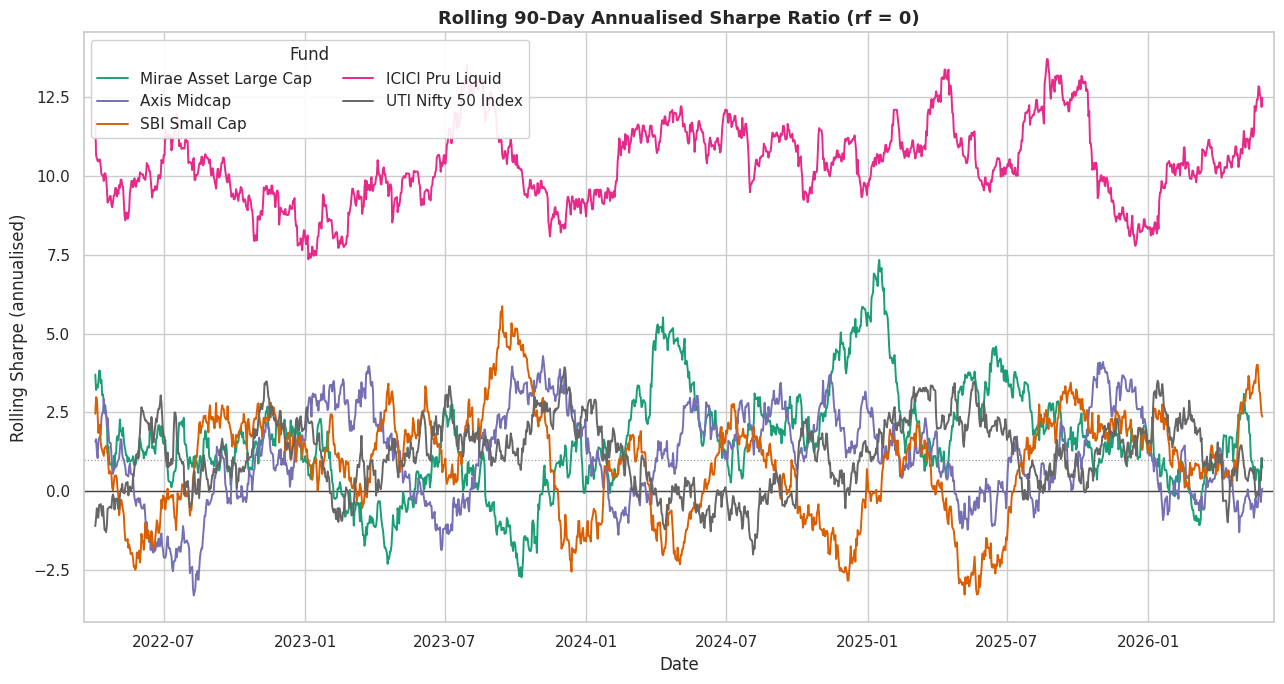

In [13]:
fig, ax = plt.subplots(figsize=(13, 7))
palette = {
    "Mirae Asset Large Cap": "#1b9e77",
    "Axis Midcap": "#7570b3",
    "SBI Small Cap": "#d95f02",
    "ICICI Pru Liquid": "#e7298a",
    "UTI Nifty 50 Index": "#666666",
}
for short, df in series.items():
    ax.plot(df["date"], df["rolling_sharpe"], label=short, color=palette[short], linewidth=1.4)

ax.axhline(0, color="#444444", linewidth=1.0, zorder=1)
ax.axhline(1, color="#999999", linewidth=0.9, linestyle=":", zorder=1)
ax.set_title("Rolling 90-Day Annualised Sharpe Ratio (rf = 0)", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe (annualised)")
ax.legend(title="Fund", loc="upper left", ncol=2, framealpha=0.9)
ax.margins(x=0.01)
plt.tight_layout()

ROLLING_CHART_PATH = CHARTS_DIR / "rolling_sharpe_chart.png"
fig.savefig(ROLLING_CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {ROLLING_CHART_PATH}")
plt.show()

### 2.7 Insights

*All figures are the actual values computed above — 5 funds, **1,518** rolling 90-day Sharpe values each,
spanning **2022-04-03 → 2026-05-29** (the rolling window begins ~90 trading days after the 2022-01-03
return start). Risk-free rate = 0; Sharpe is annualised by $\sqrt{252}$.*

**Stability of Sharpe through time.** Two completely different regimes emerge. **ICICI Pru Liquid** is
in a class of its own: its rolling Sharpe averages **10.40** and *never once turns negative* (range
**+7.36 → +13.72** over all 1,518 windows) — relative to its own mean it barely moves (coefficient of
variation **0.12**). That is the signature of a fund earning small, near-monotonic positive daily
returns with tiny volatility — the Sharpe ratio's denominator is so small that the annualised ratio is
both huge and extremely stable. The four equity/index funds, by contrast, swing through the full cycle:
each crosses zero repeatedly and spends meaningful time *below* break-even (Mirae **13%** of windows
negative, UTI **18%**, Axis Midcap **25%**, SBI Small Cap **29%**).

**Most volatile Sharpe series.** By the standard deviation of the rolling-Sharpe series itself, **SBI
Small Cap is the most volatile (σ = 1.69)**, edging out Mirae Large Cap (1.64) and Axis Midcap (1.46).
Small Cap also has the widest *relative* swing — coefficient of variation **1.98**, by far the highest —
and the lowest average rolling Sharpe of the equity group (**0.85**), confirming the Day 4 / Section 1
theme: small-cap delivers its returns with the least *consistent* risk-adjusted profile. Its rolling
Sharpe ranged from a deep **−3.28** to a euphoric **+5.87**, a 9.2-point arc.

**Most consistent Sharpe series.** This depends on the lens, and both are worth stating honestly:
- **In absolute terms**, among the market-exposed funds the **UTI Nifty 50 Index** is the most
  consistent (σ = **1.11**, range −2.01 → +3.93) — diversification across 50 large-caps damps the
  swings that hit the single-segment active funds.
- **In relative terms**, **ICICI Pru Liquid** is overwhelmingly the most consistent (CoV 0.12, 0%
  negative windows) — but its near-zero denominator makes the headline Sharpe level economically
  misleading, so it is best read as "capital-preservation stability," not "10× the risk-adjusted return
  of equities."

**Latest vs through-cycle.** As of **2026-05-29** the rolling Sharpes are: ICICI Liquid **12.49**, SBI
Small Cap **2.37**, UTI Nifty **1.04**, Mirae Large Cap **0.76**, Axis Midcap **0.08**. Notably
**SBI Small Cap's latest reading (2.37) sits well above its long-run average (0.85)** — it is currently
in a strong patch — whereas **Mirae (0.76 vs avg 1.61)** and **Axis Midcap (0.08 vs avg 1.12)** are
running cooler than their own histories, a reminder that a point-in-time Sharpe can mislead without the
rolling context.

**Implications.**
- **Don't compare liquid-fund Sharpe to equity Sharpe at face value** — the tiny-denominator effect
  inflates it ~10×. Within a peer group (the four market funds) the rolling Sharpe is a fair, like-for-
  like consistency gauge.
- **Index beats single-segment active on consistency.** The Nifty 50 index fund delivered an average
  rolling Sharpe (1.18) close to the active mid/large-cap funds but with the smallest swings — a
  concrete argument for the index as a low-volatility core holding.
- **Read the trend, not the snapshot.** Funds drift far from their own average Sharpe; the rolling view
  catches regime changes (e.g. Axis Midcap's current 0.08) that a single whole-period number hides.

**Data note.** Rolling Sharpe is backward-looking and window-sensitive — a 90-day window reacts faster
(noisier) than a 1-year window would. The forward-filled NAV days from Day 4 can insert near-zero
returns that *slightly compress* a window's volatility; this nudges the Sharpe level marginally but does
not change the stability *ranking* across funds.

## 3. Investor Cohort Analysis

A **cohort** groups investors by *when they joined* — here, the calendar year of their **first
transaction** in the dataset. Tracking cohorts answers questions a single snapshot cannot: do later
joiners invest more? Are category preferences shifting? Is the investor base growing? Every one of an
investor's transactions is attributed to their joining cohort, so a cohort's totals span its members'
entire activity, not just their first year.

**Key assumptions (documented up front, because they materially shape the read):**

1. **`total_invested` counts inflows only** — `SIP` + `Lumpsum`. `Redemption` is money *leaving*, not
   invested, so it is excluded from `total_invested` (reported separately as `total_redeemed`). This is
   the financially honest definition; including redemptions would overstate "investment".
2. **`average_transaction_amount` = `total_invested` / `inflow_transactions`** — the average *inflow*
   ticket size. Using the inflow count (not all transactions) keeps the average a meaningful investment
   figure rather than blending in withdrawals.
3. **Left-censoring & truncation.** The data spans **2024-01-01 → 2025-05-30** only. Anyone already
   transacting when the window opens is tagged to **2024**, and the **2025** cohort is observed for just
   ~5 months. Raw cohort-size differences therefore reflect the *observation window*, not true customer
   acquisition — we flag this wherever it matters and avoid over-claiming "growth".

### 3.1 Load datasets and attach category

Load the cleaned investor transactions and the fund master, then merge `category` and `scheme_name`
onto every transaction via `amfi_code` (an inner-equivalent left join — all transaction `amfi_code`s
are known to exist in the master).

In [14]:
txns = pd.read_csv(PROCESSED_DIR / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
master = pd.read_csv(RAW_DIR / "01_fund_master.csv")

txns = txns.merge(master[["amfi_code", "category", "scheme_name"]], on="amfi_code", how="left")

assert txns["category"].notna().all(), "Some transactions did not match a fund category"
print(f"Transactions : {len(txns):,} rows  ·  {txns['investor_id'].nunique():,} investors")
print(f"Date span    : {txns['transaction_date'].min().date()} -> {txns['transaction_date'].max().date()}")
print(f"Types        : {txns['transaction_type'].value_counts().to_dict()}")
print(f"Categories   : {txns['category'].value_counts().to_dict()}")

Transactions : 32,778 rows  ·  5,000 investors
Date span    : 2024-01-01 -> 2025-05-30
Types        : {'SIP': 19716, 'Lumpsum': 8095, 'Redemption': 4967}
Categories   : {'Equity': 27853, 'Debt': 4925}


### 3.2 Assign each investor to a cohort

For each investor, find the **earliest** `transaction_date`, take its **year**, and broadcast that
`cohort_year` back onto every one of their transactions. Because the assignment derives from a single
per-investor minimum, each investor lands in exactly one cohort by construction.

In [15]:
first_txn = txns.groupby("investor_id")["transaction_date"].transform("min")
txns["cohort_year"] = first_txn.dt.year

# Flag inflows once for reuse
txns["is_inflow"] = txns["transaction_type"].isin(["SIP", "Lumpsum"])

cohort_years = sorted(txns["cohort_year"].unique())
print(f"Cohort years found : {cohort_years}")
print("Investors per cohort (by first transaction):")
print(txns.drop_duplicates("investor_id")["cohort_year"].value_counts().sort_index().to_string())

Cohort years found : [np.int32(2024), np.int32(2025)]
Investors per cohort (by first transaction):
cohort_year
2024    4803
2025     197


### 3.3 Build the cohort table

Aggregate per `cohort_year`. Core metrics (`investor_count`, `total_transactions`, `total_invested`,
`average_transaction_amount`) plus the **category-preference** block (Equity/Debt transaction counts and
shares, and `top_category`). Helper columns `inflow_transactions` and `total_redeemed` are carried for
transparency and to make the average and the reconciliation auditable.

In [16]:
def summarise(group: pd.DataFrame) -> pd.Series:
    inflows = group[group["is_inflow"]]
    eq = int((group["category"] == "Equity").sum())
    db = int((group["category"] == "Debt").sum())
    n = len(group)
    invested = inflows["amount_inr"].sum()
    return pd.Series({
        "investor_count": group["investor_id"].nunique(),
        "total_transactions": n,
        "inflow_transactions": len(inflows),
        "total_invested": invested,
        "average_transaction_amount": invested / len(inflows),
        "total_redeemed": group.loc[group["transaction_type"] == "Redemption", "amount_inr"].sum(),
        "equity_txn_count": eq,
        "debt_txn_count": db,
        "equity_pct": 100 * eq / n,
        "debt_pct": 100 * db / n,
        "top_category": "Equity" if eq >= db else "Debt",
    })

cohort_analysis = (
    txns.groupby("cohort_year").apply(summarise, include_groups=False).reset_index()
)
# Integer types for count columns
for col in ["investor_count", "total_transactions", "inflow_transactions",
            "equity_txn_count", "debt_txn_count"]:
    cohort_analysis[col] = cohort_analysis[col].astype(int)

cohort_analysis.round(2)

,cohort_year,investor_count,total_transactions,inflow_transactions,total_invested,average_transaction_amount,total_redeemed,equity_txn_count,debt_txn_count,equity_pct,debt_pct,top_category
0,2024,4803,32499,27578,2.258062e+09,81879.12,1.233063e+09,27621,4878,84.99,15.01,Equity
1,2025,197,279,233,1.899264e+07,81513.45,1.146261e+07,232,47,83.15,16.85,Equity


### 3.4 Validate

1. **One cohort per investor** — every investor maps to exactly one `cohort_year`.
2. **No missing cohort assignments** — no null `cohort_year`.
3. **Reconciliation** — cohort sums equal the source totals for investors, transactions and invested
   rupees (every transaction belongs to exactly one investor → one cohort).
4. **Category percentages** — `equity_pct + debt_pct = 100` for each cohort (the only two categories).

In [17]:
# 1) One cohort per investor
per_investor = txns.groupby("investor_id")["cohort_year"].nunique()
assert (per_investor == 1).all(), "Some investors span multiple cohorts"
print(f"One cohort per investor — OK ({len(per_investor):,} investors)")

# 2) No missing cohort assignments
assert txns["cohort_year"].notna().all(), "Null cohort assignments found"
print("No missing cohort assignments — OK")

# 3) Reconciliation against source
src_investors = txns["investor_id"].nunique()
src_txns = len(txns)
src_invested = txns.loc[txns["is_inflow"], "amount_inr"].sum()
assert cohort_analysis["investor_count"].sum() == src_investors, "Investor count mismatch"
assert cohort_analysis["total_transactions"].sum() == src_txns, "Transaction count mismatch"
assert abs(cohort_analysis["total_invested"].sum() - src_invested) < 1e-6, "Invested total mismatch"
print(f"Reconciliation — OK")
print(f"   investors    : {cohort_analysis['investor_count'].sum():,} == {src_investors:,}")
print(f"   transactions : {cohort_analysis['total_transactions'].sum():,} == {src_txns:,}")
print(f"   invested INR : {cohort_analysis['total_invested'].sum():,.0f} == {src_invested:,.0f}")

# 4) Category percentages sum to 100
pct_sum = (cohort_analysis["equity_pct"] + cohort_analysis["debt_pct"]).round(6)
assert (pct_sum == 100).all(), f"Category percentages do not sum to 100: {pct_sum.tolist()}"
print(f"Category percentages sum to 100 for every cohort — OK")

print("\nAll cohort validations passed.")

One cohort per investor — OK (5,000 investors)
No missing cohort assignments — OK
Reconciliation — OK
   investors    : 5,000 == 5,000
   transactions : 32,778 == 32,778
   invested INR : 2,277,054,939 == 2,277,054,939
Category percentages sum to 100 for every cohort — OK

All cohort validations passed.


### 3.5 Save the cohort table

Persist to `data/processed/cohort_analysis.csv` (raw rupee values, not rounded) and reload to confirm
the schema.

In [18]:
COHORT_PATH = PROCESSED_DIR / "cohort_analysis.csv"
cohort_analysis.to_csv(COHORT_PATH, index=False)
print(f"Saved {len(cohort_analysis)} cohorts -> {COHORT_PATH}")

reloaded = pd.read_csv(COHORT_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded)}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 2 cohorts -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/cohort_analysis.csv
Columns: ['cohort_year', 'investor_count', 'total_transactions', 'inflow_transactions', 'total_invested', 'average_transaction_amount', 'total_redeemed', 'equity_txn_count', 'debt_txn_count', 'equity_pct', 'debt_pct', 'top_category']
Reloaded rows: 2  ·  missing: 0


### 3.6 Cohort comparison chart

Four panels compare the cohorts on the dimensions the brief calls out: **investor count**, **total
invested**, **average inflow ticket**, and **category mix**. Because the 2024 cohort dwarfs 2025 in
absolute scale (a window effect — see assumptions), the first two panels use value labels so the small
2025 bar stays legible, and the category panel uses *shares* so the two cohorts are comparable on equal
footing.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/cohort_analysis.png


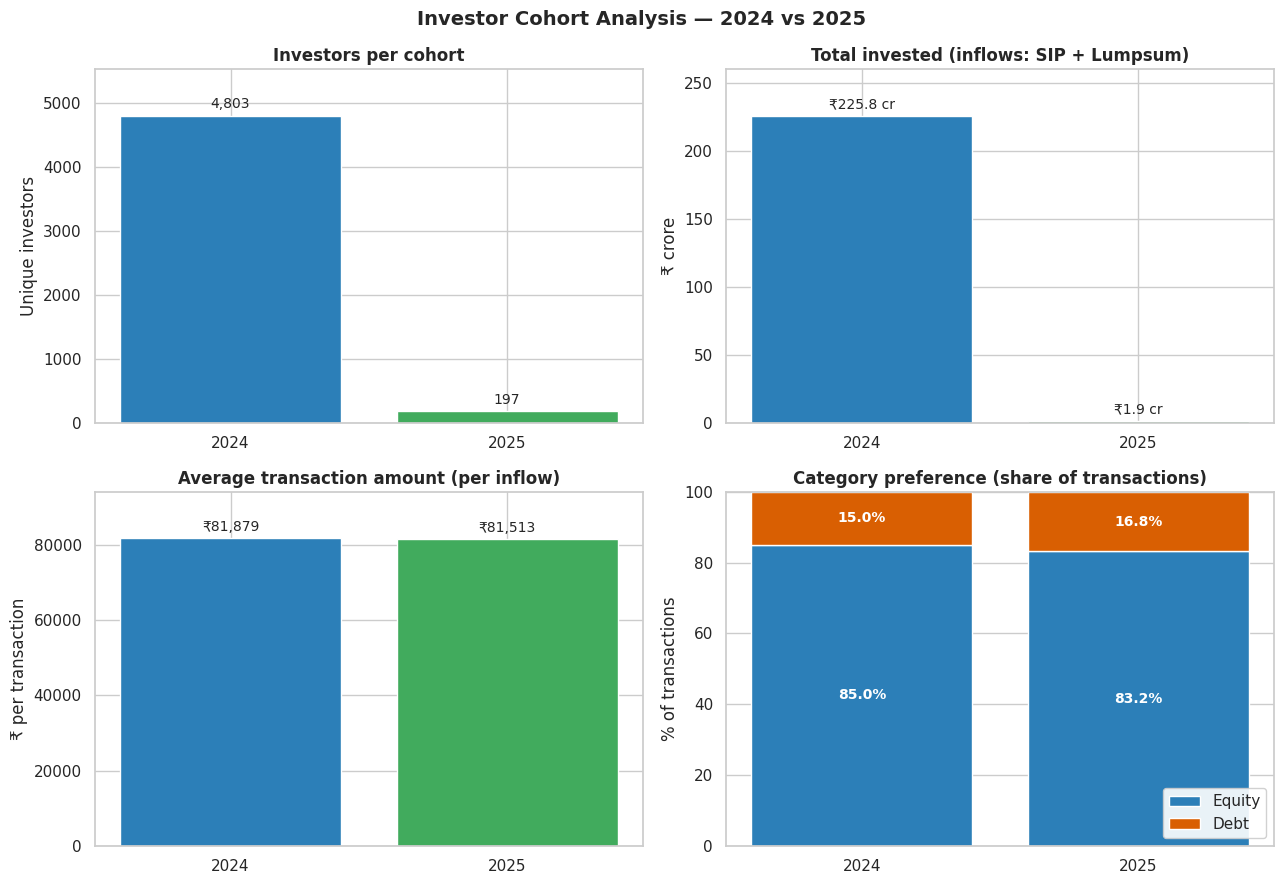

In [19]:
ca = cohort_analysis.set_index("cohort_year")
years = ca.index.astype(str).tolist()
bar_colors = ["#2c7fb8", "#41ab5d"]   # one per cohort

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Investor count
ax = axes[0, 0]
b = ax.bar(years, ca["investor_count"], color=bar_colors)
ax.bar_label(b, fmt="{:,.0f}", padding=3, fontsize=10)
ax.set_title("Investors per cohort", weight="bold")
ax.set_ylabel("Unique investors")
ax.margins(y=0.15)

# (b) Total invested (crore)
ax = axes[0, 1]
invested_cr = ca["total_invested"] / 1e7
b = ax.bar(years, invested_cr, color=bar_colors)
ax.bar_label(b, fmt="₹{:,.1f} cr", padding=3, fontsize=10)
ax.set_title("Total invested (inflows: SIP + Lumpsum)", weight="bold")
ax.set_ylabel("₹ crore")
ax.margins(y=0.15)

# (c) Average inflow ticket
ax = axes[1, 0]
b = ax.bar(years, ca["average_transaction_amount"], color=bar_colors)
ax.bar_label(b, fmt="₹{:,.0f}", padding=3, fontsize=10)
ax.set_title("Average transaction amount (per inflow)", weight="bold")
ax.set_ylabel("₹ per transaction")
ax.margins(y=0.15)

# (d) Category mix (share of transactions)
ax = axes[1, 1]
x = np.arange(len(years))
ax.bar(x, ca["equity_pct"], color="#2c7fb8", label="Equity")
ax.bar(x, ca["debt_pct"], bottom=ca["equity_pct"], color="#d95f02", label="Debt")
for i, (eq, db) in enumerate(zip(ca["equity_pct"], ca["debt_pct"])):
    ax.text(i, eq / 2, f"{eq:.1f}%", ha="center", va="center", color="white", fontsize=10, weight="bold")
    ax.text(i, eq + db / 2, f"{db:.1f}%", ha="center", va="center", color="white", fontsize=10, weight="bold")
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_title("Category preference (share of transactions)", weight="bold")
ax.set_ylabel("% of transactions")
ax.legend(loc="lower right", framealpha=0.9)
ax.set_ylim(0, 100)

fig.suptitle("Investor Cohort Analysis — 2024 vs 2025", fontsize=14, weight="bold")
plt.tight_layout()

COHORT_CHART_PATH = CHARTS_DIR / "cohort_analysis.png"
fig.savefig(COHORT_CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {COHORT_CHART_PATH}")
plt.show()

### 3.7 Insights

*All figures are the actual values computed above. Source: 32,778 transactions from 5,000 investors over
**2024-01-01 → 2025-05-30**. `total_invested` = SIP + Lumpsum inflows (redemptions excluded).*

**The dataset yields exactly two cohorts — 2024 and 2025 — and 2024 dominates by construction.** The
**2024 cohort has 4,803 investors (96.1% of all 5,000)** versus just **197 in 2025 (3.9%)**. This is
**not** a 96% collapse in customer acquisition: because the data opens on 2024-01-01, every pre-existing
investor is *left-censored* into 2024, and the 2025 cohort is observed for only ~5 months. The cohort
*sizes* are therefore an artefact of the observation window; the *behavioural* comparisons below
(per-investor amounts, ticket sizes, category mix) are the trustworthy signal.

**Which cohort invests more — in total vs per head.** In absolute terms 2024 invests far more —
**₹225.81 crore** vs **₹1.90 crore** — but that simply tracks the 24× difference in cohort size and
exposure time. **Per investor**, the 2024 cohort still invests more: **≈₹4.70 lakh each** (₹225.81 cr /
4,803) against **≈₹0.96 lakh each** for 2025 (₹1.90 cr / 197) — though the 2024 figure accumulates over
up to 17 months of activity while 2025 has ~5, so even the per-head gap is partly a time-exposure
effect, not purely a propensity difference.

**Which cohort has the larger average transaction — essentially a tie.** The average inflow ticket is
**₹81,879 (2024)** vs **₹81,513 (2025)** — a difference of just **₹366 (~0.4%)**, with 2024 marginally
ahead. Despite the cohorts differing wildly in size and tenure, the *typical* amount an investor commits
per inflow is remarkably stable across joining years — a sign of consistent product/ticket behaviour
rather than a shift in investor wallet size.

**Category preferences — both cohorts are strongly equity-led, 2025 slightly less so.** By transaction
count, **2024 is 84.99% Equity / 15.01% Debt** and **2025 is 83.15% Equity / 16.85% Debt**; **Equity is
the top category for both**. The newer cohort tilts ~1.8 points *more* toward Debt — a small move that,
if it continued, would hint at later joiners being marginally more risk-aware, but the 2025 sample (279
transactions) is too thin to call a trend.

**Activity per investor.** The 2024 cohort averages **6.8 transactions per investor** (32,499 / 4,803)
versus **1.4 for 2025** (279 / 197) — again a tenure effect: 2024 members have had far longer to make
repeat SIPs and top-ups. The redemption side reconciles too: 2024 redeemed **₹123.31 crore** and 2025
**₹1.15 crore**, so both cohorts are net positive (inflows > redemptions) over the window.

**Explicit 2024 vs 2025 summary.**
| Dimension | 2024 | 2025 | Verdict |
|---|---|---|---|
| Investors | 4,803 | 197 | 2024 (window-driven) |
| Total invested | ₹225.81 cr | ₹1.90 cr | 2024 |
| Invested per investor | ≈₹4.70 L | ≈₹0.96 L | 2024 (partly tenure) |
| Avg transaction | ₹81,879 | ₹81,513 | 2024, by ~0.4% (tie) |
| Equity share | 85.0% | 83.2% | Both Equity-led; 2025 slightly more Debt |
| Investor growth | — | −95.9% vs 2024 | **Not meaningful** — left-censoring + 5-month 2025 window |

**Implications & caveats.**
- **Don't read cohort size as acquisition.** The honest takeaway on "growth" is that the window makes it
  unmeasurable here; a true acquisition curve needs data that starts before the first investor joined.
- **Ticket size is a stable design parameter.** ~₹81–82k average inflow across both cohorts suggests
  pricing/SIP defaults, not joining year, drive ticket size.
- **Equity dominance is structural**, consistent with the fund universe itself being 34 Equity / 6 Debt
  schemes (Section 1) — investor behaviour and product supply reinforce each other.

## 4. SIP Continuation Analysis

A **Systematic Investment Plan (SIP)** is a standing commitment to invest at a regular cadence (usually
monthly). Its whole value proposition — rupee-cost averaging, compounding, discipline — depends on
*continuity*. This section measures how regularly each investor actually contributes, and flags those
whose cadence has slipped.

For every investor we sort their SIP transactions, measure the **calendar-day gap between consecutive
SIPs**, and summarise the rhythm (`average`, `median`, `max` gap). We then keep only investors with a
meaningful history and classify each as **Healthy** or **At Risk**.

**Assumptions (documented up front):**

1. **SIP only.** We filter to `transaction_type == "SIP"`; `Lumpsum` and `Redemption` are not part of a
   recurring plan and are excluded.
2. **Gap = days between consecutive SIP dates** (`diff().dt.days`). Note that the mean of consecutive
   gaps equals `(last_sip - first_sip) / (sip_count - 1)` — the two are algebraically identical, so
   `average_gap_days` is unambiguous.
3. **Eligibility ≥ 6 SIPs.** A fair continuity read needs several intervals; 6 SIPs gives ≥ 5 gaps. This
   also guarantees every gap metric is defined (no single-transaction `NaN`).
4. **Healthy ≤ 35 days.** This threshold assumes the *intended* cadence is **monthly** (~30 days + a few
   days of slack). As the results show, the dataset's SIPs actually run at roughly **double** that
   spacing, so almost everyone lands in "At Risk" — we report this faithfully and discuss what it means
   for the threshold rather than tuning the number to get a prettier split.

### 4.1 Load transactions and filter to SIPs

Load the cleaned investor transactions and keep only `SIP` rows.

In [20]:
txns = pd.read_csv(PROCESSED_DIR / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
sip = txns[txns["transaction_type"] == "SIP"].copy()

print(f"All transactions : {len(txns):,}")
print(f"SIP transactions : {len(sip):,}  ·  {sip['investor_id'].nunique():,} investors")
print(f"SIP date span    : {sip['transaction_date'].min().date()} -> {sip['transaction_date'].max().date()}")

All transactions : 32,778
SIP transactions : 19,716  ·  4,762 investors
SIP date span    : 2024-01-01 -> 2025-05-30


### 4.2 Compute per-investor SIP cadence

Sort each investor's SIPs by date, take consecutive day gaps, and summarise. The first SIP has no prior
gap, so an investor with `sip_count` SIPs contributes `sip_count − 1` gaps.

In [21]:
sip = sip.sort_values(["investor_id", "transaction_date"])

def sip_metrics(group: pd.DataFrame) -> pd.Series:
    dates = group["transaction_date"]
    gaps = dates.diff().dt.days.dropna()        # consecutive-day gaps (n-1 of them)
    return pd.Series({
        "sip_count": len(group),
        "first_sip_date": dates.min(),
        "last_sip_date": dates.max(),
        "average_gap_days": gaps.mean(),
        "median_gap_days": gaps.median(),
        "max_gap_days": gaps.max(),
    })

continuity = sip.groupby("investor_id").apply(sip_metrics, include_groups=False).reset_index()
print(f"Investors with >=1 SIP: {len(continuity):,}")
print("SIP-count distribution (all SIP investors):")
print(continuity["sip_count"].describe()[["min", "25%", "50%", "75%", "max"]].astype(int).to_string())

Investors with >=1 SIP: 4,762
SIP-count distribution (all SIP investors):
min     1
25%     2
50%     4
75%     6
max    12


### 4.3 Apply eligibility and risk classification

Keep investors with **≥ 6 SIPs**, then classify: **Healthy** if `average_gap_days ≤ 35`, otherwise
**At Risk**.

In [22]:
ELIGIBLE_MIN_SIPS = 6
HEALTHY_MAX_GAP = 35

sip_continuity = continuity[continuity["sip_count"] >= ELIGIBLE_MIN_SIPS].copy()
sip_continuity["status"] = np.where(
    sip_continuity["average_gap_days"] <= HEALTHY_MAX_GAP, "Healthy", "At Risk"
)
sip_continuity["sip_count"] = sip_continuity["sip_count"].astype(int)
sip_continuity["max_gap_days"] = sip_continuity["max_gap_days"].astype(int)
sip_continuity = sip_continuity.sort_values("average_gap_days").reset_index(drop=True)

n_total = len(sip_continuity)
n_healthy = int((sip_continuity["status"] == "Healthy").sum())
n_at_risk = int((sip_continuity["status"] == "At Risk").sum())
print(f"Eligible investors (>= {ELIGIBLE_MIN_SIPS} SIPs): {n_total:,}  "
      f"({100*n_total/len(continuity):.1f}% of SIP investors)")
print(f"  Healthy (avg gap <= {HEALTHY_MAX_GAP}d): {n_healthy:,}  ({100*n_healthy/n_total:.1f}%)")
print(f"  At Risk (avg gap >  {HEALTHY_MAX_GAP}d): {n_at_risk:,}  ({100*n_at_risk/n_total:.1f}%)")

Eligible investors (>= 6 SIPs): 1,362  (28.6% of SIP investors)
  Healthy (avg gap <= 35d): 30  (2.2%)
  At Risk (avg gap >  35d): 1,332  (97.8%)


### 4.4 Validate

1. **No duplicate investors** — one row per investor.
2. **`average_gap_days > 0`** — gaps are strictly positive (no same-day duplicate SIPs collapsing a gap
   to zero).
3. **`last_sip_date ≥ first_sip_date`** — chronology holds.
4. **Eligibility** — every included investor has **≥ 6 SIPs**.
5. **Reconciliation** — Healthy + At Risk equals the eligible total.

In [23]:
# 1) No duplicate investors
assert sip_continuity["investor_id"].is_unique, "Duplicate investor rows found"
print(f"No duplicate investors — OK ({n_total:,} rows)")

# 2) average_gap_days > 0
assert (sip_continuity["average_gap_days"] > 0).all(), "Non-positive average gap found"
print(f"average_gap_days > 0 for all — OK (min {sip_continuity['average_gap_days'].min():.2f}d)")

# 3) Chronology
assert (sip_continuity["last_sip_date"] >= sip_continuity["first_sip_date"]).all(), "last < first"
print("last_sip_date >= first_sip_date for all — OK")

# 4) Eligibility
assert (sip_continuity["sip_count"] >= ELIGIBLE_MIN_SIPS).all(), "Investor with < 6 SIPs slipped in"
print(f"Every investor has >= {ELIGIBLE_MIN_SIPS} SIPs — OK (min {sip_continuity['sip_count'].min()})")

# 5) Reconciliation
assert n_healthy + n_at_risk == n_total, "Status counts do not reconcile"
print(f"Healthy ({n_healthy:,}) + At Risk ({n_at_risk:,}) = {n_total:,} eligible — OK")

print("\nAll SIP-continuity validations passed.")

No duplicate investors — OK (1,362 rows)
average_gap_days > 0 for all — OK (min 19.80d)
last_sip_date >= first_sip_date for all — OK
Every investor has >= 6 SIPs — OK (min 6)
Healthy (30) + At Risk (1,332) = 1,362 eligible — OK

All SIP-continuity validations passed.


### 4.5 Save the continuity table

Persist to `data/processed/sip_continuity.csv` and reload to confirm the schema.

In [24]:
SIP_CONT_PATH = PROCESSED_DIR / "sip_continuity.csv"
sip_continuity.to_csv(SIP_CONT_PATH, index=False)
print(f"Saved {len(sip_continuity):,} investors -> {SIP_CONT_PATH}")

reloaded = pd.read_csv(SIP_CONT_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded):,}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 1,362 investors -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/sip_continuity.csv
Columns: ['investor_id', 'sip_count', 'first_sip_date', 'last_sip_date', 'average_gap_days', 'median_gap_days', 'max_gap_days', 'status']
Reloaded rows: 1,362  ·  missing: 0


### 4.6 Charts

Two views: **(a)** the distribution of `average_gap_days` with the 35-day Healthy threshold marked, and
**(b)** the Healthy vs At Risk headcount. The histogram makes plain *why* the split is so lopsided — the
mass of investors sits well to the right of the 35-day line, around a ~2-month cadence.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/sip_continuity_histogram.png


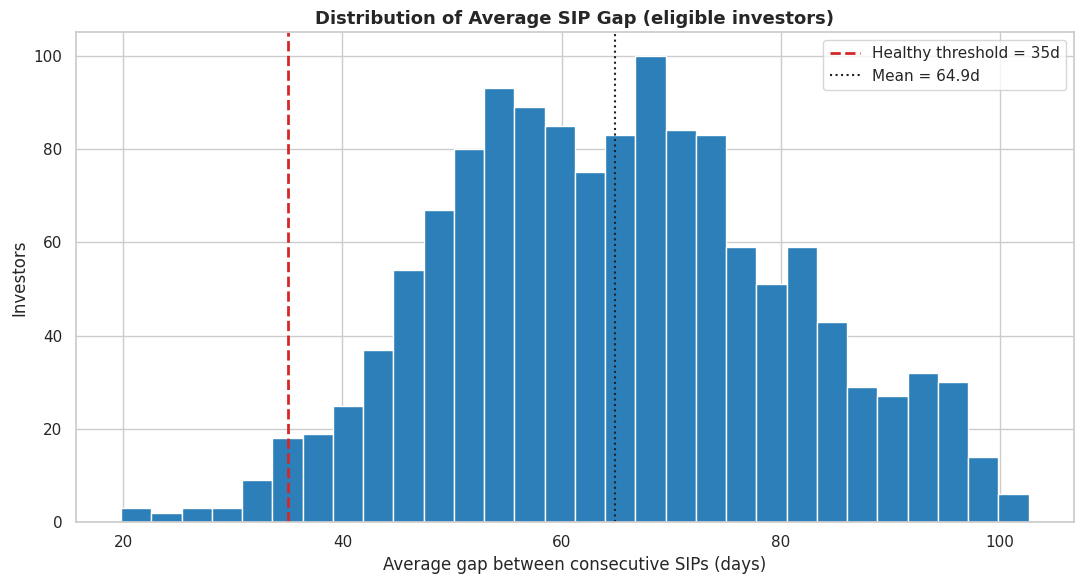

In [25]:
# (a) Histogram of average gap days
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(sip_continuity["average_gap_days"], bins=30, color="#2c7fb8", edgecolor="white")
ax.axvline(HEALTHY_MAX_GAP, color="#d62728", linewidth=2, linestyle="--",
           label=f"Healthy threshold = {HEALTHY_MAX_GAP}d")
mean_gap = sip_continuity["average_gap_days"].mean()
ax.axvline(mean_gap, color="#222222", linewidth=1.5, linestyle=":",
           label=f"Mean = {mean_gap:.1f}d")
ax.set_title("Distribution of Average SIP Gap (eligible investors)", fontsize=13, weight="bold")
ax.set_xlabel("Average gap between consecutive SIPs (days)")
ax.set_ylabel("Investors")
ax.legend()
plt.tight_layout()
HIST_PATH = CHARTS_DIR / "sip_continuity_histogram.png"
fig.savefig(HIST_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {HIST_PATH}")
plt.show()

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/sip_continuity_status.png


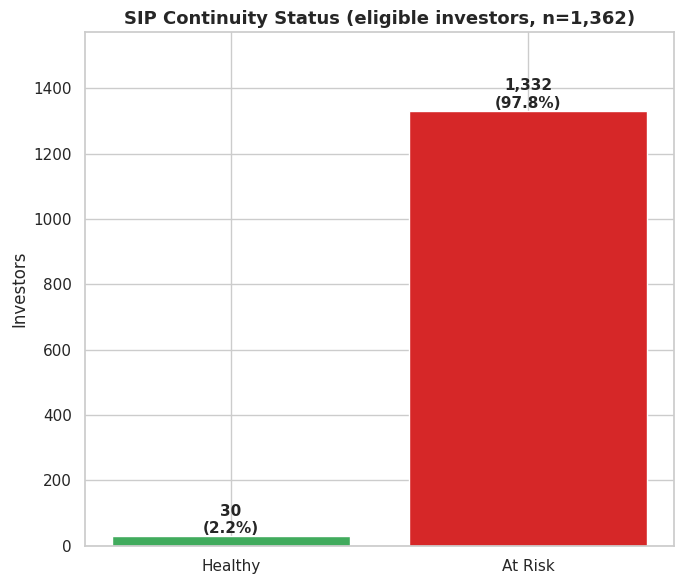

In [26]:
# (b) Healthy vs At Risk status
fig, ax = plt.subplots(figsize=(7, 6))
status_counts = sip_continuity["status"].value_counts().reindex(["Healthy", "At Risk"])
colors = {"Healthy": "#41ab5d", "At Risk": "#d62728"}
bars = ax.bar(status_counts.index, status_counts.values,
              color=[colors[s] for s in status_counts.index])
for bar, v in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({100*v/n_total:.1f}%)",
            ha="center", va="bottom", fontsize=11, weight="bold")
ax.set_title(f"SIP Continuity Status (eligible investors, n={n_total:,})", fontsize=13, weight="bold")
ax.set_ylabel("Investors")
ax.margins(y=0.18)
plt.tight_layout()
STATUS_PATH = CHARTS_DIR / "sip_continuity_status.png"
fig.savefig(STATUS_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {STATUS_PATH}")
plt.show()

### 4.7 Insights

*All figures are the actual values computed above. Source: 19,716 SIP transactions from 4,762 SIP
investors over **2024-01-01 → 2025-05-30**; analysis restricted to the **1,362** investors with ≥ 6
SIPs.*

**Headcount — the split is extreme.** Of the 1,362 eligible investors, only **30 are Healthy (2.2%)**
and **1,332 are At Risk (97.8%)**. That near-universal "At Risk" verdict is not noise — it is the direct
consequence of the cadence in the data versus the monthly assumption baked into the 35-day threshold.

**Average SIP gap — the data runs at ~2 months, not 1.** Across eligible investors the **average gap is
64.9 days (median 64.7)** — roughly *double* a monthly cadence. Healthy investors average a **30.3-day**
gap (median 32.5, i.e. genuinely monthly), while At Risk investors average **65.7 days** (median 65.0).
The whole distribution sits to the right of the 35-day line (see histogram), clustering in the 45–90 day
range, so the binary classification is really separating a small monthly minority from a bi-monthly
majority.

**Largest observed gap — real lapses exist independent of the threshold.** The **single largest gap is
372 days** — over a full year between two SIPs. More broadly, **1,256 eligible investors (92%) had at
least one gap exceeding 90 days**, and **428 (31%) had a gap exceeding 180 days**. Even the Healthy
group is not immune: their *average* is monthly, but their mean *maximum* gap is **76 days**, so a steady
contributor can still have one long pause.

**Eligibility context.** Only **28.6%** of SIP investors (1,362 of 4,762) reached the 6-SIP bar within
the ~17-month window; the median SIP investor made just **4** contributions. So the continuity question
is, for now, only answerable for a committed minority — the rest simply do not yet have enough history.

**Retention implications.**
- **Recalibrate the threshold to the product's real cadence.** A 35-day "Healthy" cut assumes monthly
  SIPs, but this book's SIPs are effectively **bi-monthly (~65 days)**. If that spacing is *by design*
  (e.g. the platform offers/encourages bi-monthly plans), the threshold should move to ~70 days and the
  picture inverts; if it reflects investors *missing* monthly debits, then a genuine retention problem is
  widespread. Either way, the absolute number must be set against the intended cadence — the current
  result flags a **definition mismatch as much as a behaviour problem**, and that distinction should be
  resolved with product/mandate data before acting.
- **Watch `max_gap`, not just the average.** The 372-day lapse and the 428 investors with >180-day gaps
  are unambiguous interruptions regardless of threshold — these are the highest-value targets for a
  re-engagement nudge, because a stalled SIP forfeits exactly the compounding and cost-averaging the
  product is sold on.
- **Grow the eligible base.** With only 28.6% reaching 6 SIPs, the first retention win is simply getting
  more investors past the early-drop-off phase; continuity quality is a second-order problem behind
  early persistence.

**Data note.** Gaps are calendar days, so weekends/holidays inflate a "monthly" gap slightly above 30,
which is why the Healthy threshold allows slack to 35. The ~17-month window right-censors cadence (an
investor who paused near the end looks At Risk even if they resume later), so these labels describe the
observed window, not a permanent verdict.

## 5. Fund Recommendation Engine

The final section turns the analytics into a simple, transparent **recommendation engine**: given an
investor's **risk profile**, return the three best funds for that profile. "Best" is defined by the
**Sharpe ratio** computed in Day 4 (Section 3) — return earned per unit of total risk.

The design is deliberately rule-based and auditable (no black box): map each fund to a risk bucket by
its `sub_category`, rank within the bucket by Sharpe, and take the top 3. The output table is exported
and also served by a small reusable module, `src/recommender.py`.

**Why risk buckets exist.** Investors differ in how much volatility they can tolerate, both
psychologically and by goal horizon. A retiree parking emergency cash and a 25-year-old building a
20-year corpus should *not* see the same shortlist. Bucketing first by risk, *then* optimising
risk-adjusted return inside the bucket, keeps recommendations suitable: we never tell a conservative
investor to buy a small-cap fund just because its Sharpe is high. The three buckets map to the standard
**capital-preservation / balanced-growth / aggressive-growth** investor archetypes.

**Why Sharpe ratio.** Within a risk bucket the funds already share a broad volatility regime, so the
right question is "who delivered the most return *per unit of risk*?" — exactly what Sharpe measures.
Ranking on raw return alone would reward whoever simply took more risk; Sharpe normalises that out,
making the comparison fair *inside* a bucket. (Its limitations, which bite hardest in the low-risk
bucket here, are discussed honestly in the insights.)

### 5.1 Load datasets and define the risk-bucket mapping

`sharpe_rankings.csv` carries the Sharpe ratio but only the broad `category` (Equity/Debt); the buckets
are defined on `sub_category`, so we merge it in from the fund master.

**Exact category mapping (from the dataset's `sub_category` values):**

| Risk profile | `sub_category` values | Funds in universe |
|---|---|---|
| **LOW RISK** | Liquid, Short Duration, Gilt | 6 |
| **MODERATE RISK** | Large Cap, Flexi Cap, Index | 17 |
| **HIGH RISK** | Mid Cap, Small Cap | 13 |

**Excluded sub-categories (documented).** Four sub-categories in the data are **not** named in the
brief's bucket definitions and are therefore left unmapped: **Value (1), Index/ETF (1), Large & Mid Cap
(1), ELSS (1)**. We map only the exact `sub_category` strings listed — e.g. `Index` (the UTI Nifty 50
Index Fund) is included, but `Index/ETF` (the Nippon ETF) is *not*, to avoid inventing a mapping the
brief did not specify. Each bucket still has ≥ 3 funds, so every profile yields a full Top-3.

In [27]:
sharpe = pd.read_csv(PROCESSED_DIR / "sharpe_rankings.csv")
master = pd.read_csv(RAW_DIR / "01_fund_master.csv")

# Attach sub_category (the buckets are defined on it, not the broad category)
funds = sharpe.merge(master[["amfi_code", "sub_category"]], on="amfi_code", how="left")
assert funds["sub_category"].notna().all(), "Some funds have no sub_category"

RISK_BUCKETS = {
    "LOW RISK": ["Liquid", "Short Duration", "Gilt"],
    "MODERATE RISK": ["Large Cap", "Flexi Cap", "Index"],
    "HIGH RISK": ["Mid Cap", "Small Cap"],
}

mapped_subs = {s for subs in RISK_BUCKETS.values() for s in subs}
excluded = sorted(set(funds["sub_category"]) - mapped_subs)
print("Funds available per bucket:")
for profile, subs in RISK_BUCKETS.items():
    n = funds["sub_category"].isin(subs).sum()
    print(f"  {profile:14s}: {n:2d} funds  ({', '.join(subs)})")
print(f"\nExcluded sub_categories (not in brief): {excluded}")
print(f"Excluded fund count: {funds['sub_category'].isin(excluded).sum()}")

Funds available per bucket:
  LOW RISK      :  6 funds  (Liquid, Short Duration, Gilt)
  MODERATE RISK : 17 funds  (Large Cap, Flexi Cap, Index)
  HIGH RISK     : 13 funds  (Mid Cap, Small Cap)

Excluded sub_categories (not in brief): ['ELSS', 'Index/ETF', 'Large & Mid Cap', 'Value']
Excluded fund count: 4


### 5.2 Rank within each bucket and take the Top 3

For each profile, filter to its sub-categories, sort by `sharpe_ratio` **descending**, and keep the top
3. `recommendation_rank` (1 = best Sharpe in the bucket) is assigned by position after sorting. Required
output columns: `risk_profile · recommendation_rank · scheme_name · category · sharpe_ratio`.

In [28]:
records = []
for profile, subs in RISK_BUCKETS.items():
    bucket = funds[funds["sub_category"].isin(subs)].sort_values(
        "sharpe_ratio", ascending=False
    ).head(3).reset_index(drop=True)
    for rank, row in bucket.iterrows():
        records.append({
            "risk_profile": profile,
            "recommendation_rank": rank + 1,
            "scheme_name": row["scheme_name"],
            "category": row["category"],
            "sharpe_ratio": row["sharpe_ratio"],
            "sub_category": row["sub_category"],   # helper for transparency
            "amfi_code": row["amfi_code"],          # helper for validation
        })

fund_recommendations = pd.DataFrame(records)
# Required columns first, helpers after
fund_recommendations = fund_recommendations[[
    "risk_profile", "recommendation_rank", "scheme_name", "category",
    "sharpe_ratio", "sub_category", "amfi_code",
]]
fund_recommendations.round(4)

,risk_profile,recommendation_rank,scheme_name,category,sharpe_ratio,sub_category,amfi_code
0,LOW RISK,1,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,-0.7431,Gilt,119120
1,LOW RISK,2,Nippon India Gilt Securities Fund - Regular - ...,Debt,-0.8506,Gilt,118636
2,LOW RISK,3,HDFC Short Term Debt Fund - Regular - Growth,Debt,-1.0399,Short Duration,100025
3,MODERATE RISK,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.0682,Large Cap,148567
4,MODERATE RISK,2,Kotak Flexicap Fund - Regular - Growth,Equity,0.9656,Flexi Cap,120843
5,MODERATE RISK,3,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.8610,Large Cap,119551
6,HIGH RISK,1,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.8833,Mid Cap,120505
7,HIGH RISK,2,DSP Midcap Fund - Regular - Growth,Equity,0.8329,Mid Cap,149323
8,HIGH RISK,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.8083,Mid Cap,100033


### 5.3 Validate

1. **Exactly 3 per profile** — every bucket returns a full Top-3.
2. **No duplicate schemes within a profile.**
3. **Recommendations exist in the fund master** — every `amfi_code` is real.
4. **Ranking matches Sharpe ordering** — within each profile, `sharpe_ratio` is non-increasing as
   `recommendation_rank` rises, and `recommendation_rank` is exactly `1, 2, 3`.

In [29]:
master_codes = set(master["amfi_code"])

for profile in RISK_BUCKETS:
    block = fund_recommendations[fund_recommendations["risk_profile"] == profile]

    # 1) Exactly 3
    assert len(block) == 3, f"{profile}: expected 3 recs, got {len(block)}"
    # 2) No duplicate schemes
    assert block["scheme_name"].is_unique, f"{profile}: duplicate scheme"
    # 3) Exist in master
    assert set(block["amfi_code"]).issubset(master_codes), f"{profile}: unknown amfi_code"
    # 4) Ranking matches Sharpe ordering
    assert block["recommendation_rank"].tolist() == [1, 2, 3], f"{profile}: rank not 1..3"
    sr = block.sort_values("recommendation_rank")["sharpe_ratio"].tolist()
    assert sr == sorted(sr, reverse=True), f"{profile}: Sharpe not descending with rank"
    print(f"{profile:14s} OK  ·  top Sharpe {sr[0]:+.4f} -> {sr[-1]:+.4f}")

assert len(fund_recommendations) == 3 * len(RISK_BUCKETS), "Total rec count mismatch"
print(f"\nTotal recommendations: {len(fund_recommendations)} (3 x {len(RISK_BUCKETS)} profiles)")
print("All recommendation validations passed.")

LOW RISK       OK  ·  top Sharpe -0.7431 -> -1.0399
MODERATE RISK  OK  ·  top Sharpe +1.0682 -> +0.8610
HIGH RISK      OK  ·  top Sharpe +0.8833 -> +0.8083

Total recommendations: 9 (3 x 3 profiles)
All recommendation validations passed.


### 5.4 Save the recommendations table

Persist to `data/processed/fund_recommendations.csv` (this is the file `src/recommender.py` reads), then
reload to confirm the schema.

In [30]:
RECS_PATH = PROCESSED_DIR / "fund_recommendations.csv"
fund_recommendations.to_csv(RECS_PATH, index=False)
print(f"Saved {len(fund_recommendations)} recommendations -> {RECS_PATH}")

reloaded = pd.read_csv(RECS_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded)}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 9 recommendations -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/fund_recommendations.csv
Columns: ['risk_profile', 'recommendation_rank', 'scheme_name', 'category', 'sharpe_ratio', 'sub_category', 'amfi_code']
Reloaded rows: 9  ·  missing: 0


### 5.5 The reusable module — `src/recommender.py`

A small module exposes `recommend(risk_profile)`, which reads the exported CSV and returns the Top-3 for
a profile (case-insensitive, with `low`/`moderate`/`high` aliases). We import and smoke-test it here so
the notebook proves the module works against the freshly-saved file.

In [31]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.recommender import recommend

# Smoke test all three profiles + an alias, and confirm parity with the in-notebook table
for profile in ["LOW RISK", "MODERATE RISK", "HIGH RISK"]:
    got = recommend(profile)
    assert len(got) == 3, f"{profile}: module returned {len(got)} rows"
    exp = (fund_recommendations[fund_recommendations["risk_profile"] == profile]
           .sort_values("recommendation_rank")["scheme_name"].tolist())
    assert got["scheme_name"].tolist() == exp, f"{profile}: module/table mismatch"
print("Module parity with notebook table — OK for all profiles")
print("Alias test recommend('high'):")
recommend("high")

Module parity with notebook table — OK for all profiles
Alias test recommend('high'):


,risk_profile,recommendation_rank,scheme_name,category,sharpe_ratio
0,HIGH RISK,1,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.883256
1,HIGH RISK,2,DSP Midcap Fund - Regular - Growth,Equity,0.832885
2,HIGH RISK,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.808268


### 5.6 Recommendations chart

A grouped horizontal view: the Top-3 Sharpe ratios for each risk profile, panelled by profile so the
very different Sharpe scales (negative in low-risk, positive in moderate/high) don't distort each other.
Bars are labelled with the exact Sharpe value.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/fund_recommendations.png


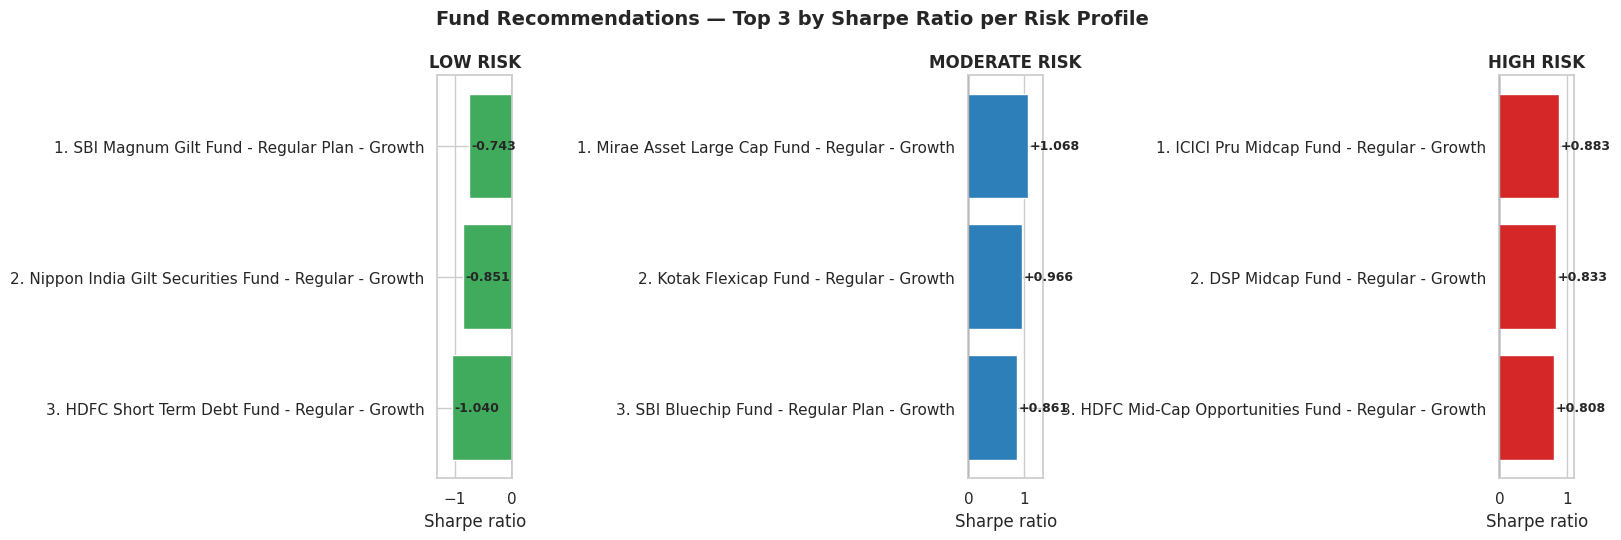

In [32]:
profiles = list(RISK_BUCKETS.keys())
panel_color = {"LOW RISK": "#41ab5d", "MODERATE RISK": "#2c7fb8", "HIGH RISK": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, profile in zip(axes, profiles):
    block = (fund_recommendations[fund_recommendations["risk_profile"] == profile]
             .sort_values("recommendation_rank", ascending=False))   # rank 1 at top
    labels = [f"{r}. {n}" for r, n in zip(block["recommendation_rank"], block["scheme_name"])]
    bars = ax.barh(labels, block["sharpe_ratio"], color=panel_color[profile])
    for bar, v in zip(bars, block["sharpe_ratio"]):
        # Always label just past the bar tip toward the outside, never over the y-tick names
        ax.text(v + 0.03, bar.get_y() + bar.get_height() / 2, f"{v:+.3f}",
                va="center", ha="left", fontsize=9, weight="bold")
    ax.axvline(0, color="#444444", linewidth=1)
    ax.set_title(profile, fontsize=12, weight="bold")
    ax.set_xlabel("Sharpe ratio")
    ax.margins(x=0.25)

fig.suptitle("Fund Recommendations — Top 3 by Sharpe Ratio per Risk Profile", fontsize=14, weight="bold")
plt.tight_layout()

RECS_CHART_PATH = CHARTS_DIR / "fund_recommendations.png"
fig.savefig(RECS_CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {RECS_CHART_PATH}")
plt.show()

### 5.7 Insights

*All figures are the actual values computed above (Sharpe ratios from Day 4, Section 3, which used an
annual **risk-free rate of 6.5%** on daily returns 2022-01-03 → 2026-05-29).*

**The recommendations.**

| Profile | Top pick (Sharpe) | #2 (Sharpe) | #3 (Sharpe) |
|---|---|---|---|
| **LOW RISK** | SBI Magnum Gilt (**−0.743**) | Nippon India Gilt Securities (**−0.851**) | HDFC Short Term Debt (**−1.040**) |
| **MODERATE RISK** | Mirae Asset Large Cap (**+1.068**) | Kotak Flexicap (**+0.966**) | SBI Bluechip (**+0.861**) |
| **HIGH RISK** | ICICI Pru Midcap (**+0.883**) | DSP Midcap (**+0.833**) | HDFC Mid-Cap Opportunities (**+0.808**) |

**Moderate risk is the sweet spot on this data.** The single best risk-adjusted fund in the *entire*
recommendable universe is **Mirae Asset Large Cap (Sharpe +1.068)** — it tops the moderate bucket and
beats every high-risk pick. That is the textbook result: large-caps delivered most of the return with
materially less volatility than mid/small-caps, so they win on *risk-adjusted* terms even though
high-risk funds win on raw return (see Day 4 / Section 1).

**High risk: mid-caps edge out small-caps.** All three high-risk picks are **Mid Cap** (ICICI Pru, DSP,
HDFC; Sharpe +0.88 → +0.81). No small-cap made the top 3 — consistent with Sections 1 and 4: small-caps
carried the deepest tail risk (CVaR) and the most volatile rolling Sharpe, so their higher returns did
not translate into better risk-adjusted scores over this window.

**Low risk exposes a real limitation — every Sharpe here is negative.** The entire low-risk bucket
scores **below zero** (best is Gilt at −0.743; the *safest* funds, Liquid, score **worst** at −3.65 to
−4.65). This is not a data error: with a **6.5% risk-free assumption**, gilt (~4.0% return), short-
duration (~3.1%) and liquid (~4.3–4.8%) funds all **earned less than the risk-free rate**, so their
*excess* return is negative. Liquid funds look worst because Sharpe divides that small negative excess by
their near-zero volatility (~0.46%), exploding the ratio. So within low-risk, Sharpe ranks funds by "who
came *closest* to the risk-free rate," which is why two gilt funds top the bucket — a meaningful ordering,
but a counter-intuitive one that must be read with care.

**Strengths of this approach.**
- **Suitability-first.** Bucketing by risk *before* optimising return guarantees we never recommend an
  unsuitable fund (no small-caps to conservative investors). Risk profile is honoured by construction.
- **Transparent and auditable.** Every recommendation traces to one number (Sharpe) and one rule (top-3
  in bucket). There is no opaque scoring — an investor or compliance reviewer can verify it by hand.
- **Reusable.** `src/recommender.py` serves the same validated table programmatically, so a dashboard or
  API gets identical, reproducible answers.

**Limitations (stated honestly).**
- **Sharpe breaks down in the low-risk bucket.** A negative Sharpe makes the *least*-volatile,
  capital-preserving funds rank worst — the opposite of what a conservative investor wants. For this
  bucket a **return-over-benchmark** or **Sortino** measure (or simply ranking by yield/lowest drawdown)
  would be more appropriate; Sharpe should arguably only drive the moderate/high buckets.
- **Single-metric, single-window.** The engine ignores expense ratio, fund size, manager tenure and
  drawdown, and the Sharpe is estimated on one 2022–2026 window — a different period could reorder the
  picks. The Day 4 *scorecard* (which blends return, Sharpe, alpha, expense, drawdown) is a richer basis
  and could replace raw Sharpe in a v2.
- **Coverage gaps.** Four sub-categories (Value, Index/ETF, Large & Mid Cap, ELSS) are unmapped, so
  genuinely good funds (e.g. an ELSS for tax-savers) can never be recommended. The buckets follow the
  brief exactly; a production version would need a complete sub-category → risk taxonomy.
- **No personalisation beyond risk.** Goal horizon, tax status and liquidity needs are not considered —
  this is a *shortlist generator*, not financial advice.

## 6. Sector Concentration Risk (HHI Analysis)

A fund that puts half its money in one sector lives or dies by that sector. The
**Herfindahl–Hirschman Index (HHI)** — borrowed from competition economics — quantifies that
concentration in a single number. Applied to a portfolio's **sector weights**:

$$\text{HHI} = \sum_i w_i^2 \qquad (w_i = \text{sector } i\text{'s decimal weight})$$

HHI ranges from $1/k$ (k sectors held in equal weight — maximally diversified) up to $1$ (everything in
one sector). Its reciprocal is the intuitive companion metric:

$$\text{effective\_sectors} = \frac{1}{\text{HHI}}$$

— the *numbers-equivalent*: how many **equally-weighted** sectors would produce the same concentration.
A fund with effective_sectors ≈ 3 is, in risk terms, a 3-sector bet no matter how many sectors it
nominally lists.

**Assumptions (documented):**
1. **Equity funds only.** Concentration of *sector* exposure is an equity question; the holdings file
   covers exactly the **34 equity funds** (the 6 debt funds have no stock-level holdings), so "equity
   only" is both required and complete.
2. **Sector weights = stock weights aggregated by sector.** The holdings are stock-level; we sum
   `weight_pct` within each `(fund, sector)` to get sector weights.
3. **Normalise to decimals summing to 1.** Disclosed stock weights sum to 99.98–100.02% (rounding), so
   we divide by each fund's actual total before squaring — this removes the rounding artdefact and makes
   HHI exact. Snapshot date: **2025-12-31**.

### 6.1 Load holdings and restrict to equity funds

Load the stock-level portfolio holdings and the fund master, attach `scheme_name`/`category`, and
confirm every fund with holdings is Equity.

In [33]:
holdings = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")
master = pd.read_csv(RAW_DIR / "01_fund_master.csv")

holdings = holdings.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)
equity = holdings[holdings["category"] == "Equity"].copy()

print(f"Holdings rows        : {len(holdings)}  ·  {holdings['amfi_code'].nunique()} funds")
print(f"Equity-only rows     : {len(equity)}  ·  {equity['amfi_code'].nunique()} funds")
print(f"Non-equity in holdings: {holdings['amfi_code'].nunique() - equity['amfi_code'].nunique()}")
print(f"Snapshot date(s)     : {sorted(holdings['portfolio_date'].unique())}")

Holdings rows        : 322  ·  34 funds
Equity-only rows     : 322  ·  34 funds
Non-equity in holdings: 0
Snapshot date(s)     : ['2025-12-31']


### 6.2 Aggregate to sector weights and verify they sum to 100%

Sum stock weights within each `(fund, sector)`, then check that every fund's sector weights total ~100%
(within a 0.5-point tolerance for disclosed rounding) before normalising to decimals that sum to exactly
1.

In [34]:
sector_weights = (
    equity.groupby(["amfi_code", "sector"], as_index=False)["weight_pct"].sum()
)

# Verify the 100% sum per fund (pre-normalisation)
fund_totals = sector_weights.groupby("amfi_code")["weight_pct"].sum()
within_tol = (fund_totals - 100).abs() < 0.5
print(f"Funds with sector weights summing to ~100% (±0.5): {within_tol.sum()} / {len(fund_totals)}")
print(f"Sum range across funds: {fund_totals.min():.2f}% to {fund_totals.max():.2f}%")
assert within_tol.all(), "Some funds' sector weights do not sum to ~100%"

# Normalise to decimal weights summing to exactly 1 per fund
sector_weights["weight"] = sector_weights["weight_pct"] / sector_weights.groupby("amfi_code")["weight_pct"].transform("sum")
check = sector_weights.groupby("amfi_code")["weight"].sum()
assert np.allclose(check, 1.0), "Normalised weights do not sum to 1"
print(f"Normalised decimal weights sum to 1.0 for all funds — OK")
print(f"Sectors per fund: min {sector_weights.groupby('amfi_code').size().min()}, "
      f"max {sector_weights.groupby('amfi_code').size().max()}")

Funds with sector weights summing to ~100% (±0.5): 34 / 34
Sum range across funds: 99.98% to 100.02%
Normalised decimal weights sum to 1.0 for all funds — OK
Sectors per fund: min 6, max 10


### 6.3 Compute HHI, effective sectors and the concentration ranking

HHI = sum of squared decimal sector weights; effective_sectors = 1/HHI. Rank **1 = most concentrated**
(highest HHI), broken deterministically with `method="first"`. Required columns: `amfi_code ·
scheme_name · category · hhi · effective_sectors · concentration_rank`.

In [35]:
hhi_raw = (
    sector_weights.groupby("amfi_code")["weight"]
    .apply(lambda w: np.square(w).sum())
    .rename("hhi")
    .reset_index()
)
hhi_raw["effective_sectors"] = 1.0 / hhi_raw["hhi"]

sector_hhi = hhi_raw.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)
# rank 1 = most concentrated = highest HHI
sector_hhi["concentration_rank"] = (
    sector_hhi["hhi"].rank(ascending=False, method="first").astype(int)
)
sector_hhi = sector_hhi.sort_values("concentration_rank")[[
    "amfi_code", "scheme_name", "category", "hhi", "effective_sectors", "concentration_rank",
]].reset_index(drop=True)

print(f"Computed HHI for {len(sector_hhi)} equity funds")
sector_hhi.head(10).round(4)

Computed HHI for 34 equity funds


,amfi_code,scheme_name,category,hhi,effective_sectors,concentration_rank
0,119092,Axis Bluechip Fund - Regular - Growth,Equity,0.2968,3.3689,1
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.2551,3.9201,2
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,0.2532,3.9501,3
3,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,0.2513,3.9788,4
4,149323,DSP Midcap Fund - Regular - Growth,Equity,0.2411,4.1481,5
5,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.2386,4.1911,6
6,118635,Nippon India ETF Nifty 50 BeES,Equity,0.2375,4.2097,7
7,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,0.2324,4.3036,8
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,0.2314,4.3220,9
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.2276,4.3928,10


### 6.4 Validate

1. **Weights sum to 100%** — re-confirmed per fund (the gate in 6.2).
2. **No missing values** — every field populated.
3. **HHI > 0** and within the theoretical `(0, 1]` range.
4. **effective_sectors > 0** (and ≤ the number of sectors held).
5. **Ranks unique** — a clean `1..34`.

In [36]:
n = len(sector_hhi)

# 1) Weights sum to 100% (recheck against source)
recheck = sector_weights.groupby("amfi_code")["weight_pct"].sum()
assert ((recheck - 100).abs() < 0.5).all(), "Weight-sum check failed"
print(f"Weights sum to ~100% for all {n} funds — OK")

# 2) No missing values
assert sector_hhi.isna().sum().sum() == 0, "Missing values present"
print("No missing values — OK")

# 3) HHI > 0 and <= 1
assert (sector_hhi["hhi"] > 0).all() and (sector_hhi["hhi"] <= 1).all(), "HHI out of (0,1]"
print(f"HHI > 0 and <= 1 for all — OK (range {sector_hhi['hhi'].min():.4f}–{sector_hhi['hhi'].max():.4f})")

# 4) effective_sectors > 0
assert (sector_hhi["effective_sectors"] > 0).all(), "effective_sectors must be > 0"
sectors_held = sector_weights.groupby("amfi_code").size()
merged = sector_hhi.set_index("amfi_code")["effective_sectors"]
assert (merged <= sectors_held.reindex(merged.index) + 1e-9).all(), "effective_sectors exceeds sectors held"
print(f"effective_sectors > 0 and <= sectors held — OK (range "
      f"{sector_hhi['effective_sectors'].min():.2f}–{sector_hhi['effective_sectors'].max():.2f})")

# 5) Ranks unique 1..N
ranks = sorted(sector_hhi["concentration_rank"].tolist())
assert sector_hhi["concentration_rank"].is_unique and ranks == list(range(1, n + 1)), "Rank issue"
print(f"concentration_rank is a unique 1..{n} — OK")

print("\nAll HHI validations passed.")

Weights sum to ~100% for all 34 funds — OK
No missing values — OK
HHI > 0 and <= 1 for all — OK (range 0.1241–0.2968)
effective_sectors > 0 and <= sectors held — OK (range 3.37–8.06)
concentration_rank is a unique 1..34 — OK

All HHI validations passed.


### 6.5 Save the HHI table

Persist to `data/processed/sector_hhi.csv` and reload to confirm the schema.

In [37]:
SECTOR_HHI_PATH = PROCESSED_DIR / "sector_hhi.csv"
sector_hhi.to_csv(SECTOR_HHI_PATH, index=False)
print(f"Saved {len(sector_hhi)} funds -> {SECTOR_HHI_PATH}")

reloaded = pd.read_csv(SECTOR_HHI_PATH)
print(f"Columns: {list(reloaded.columns)}")
print(f"Reloaded rows: {len(reloaded)}  ·  missing: {reloaded.isna().sum().sum()}")

Saved 34 funds -> /Users/dheerajreddy/bluestock_mf_capstone/data/processed/sector_hhi.csv
Columns: ['amfi_code', 'scheme_name', 'category', 'hhi', 'effective_sectors', 'concentration_rank']
Reloaded rows: 34  ·  missing: 0


### 6.6 Concentration spectrum chart

All 34 equity funds, sorted most-concentrated (top) to most-diversified (bottom). Bars show HHI and are
coloured by concentration tier using the standard DOJ-style cut-offs (**< 0.15** diversified, **0.15–
0.25** moderate, **≥ 0.25** concentrated). Each bar is labelled with its **effective sector count**, and
vertical reference lines mark the two thresholds and the universe mean.

Saved chart -> /Users/dheerajreddy/bluestock_mf_capstone/reports/charts/sector_concentration.png


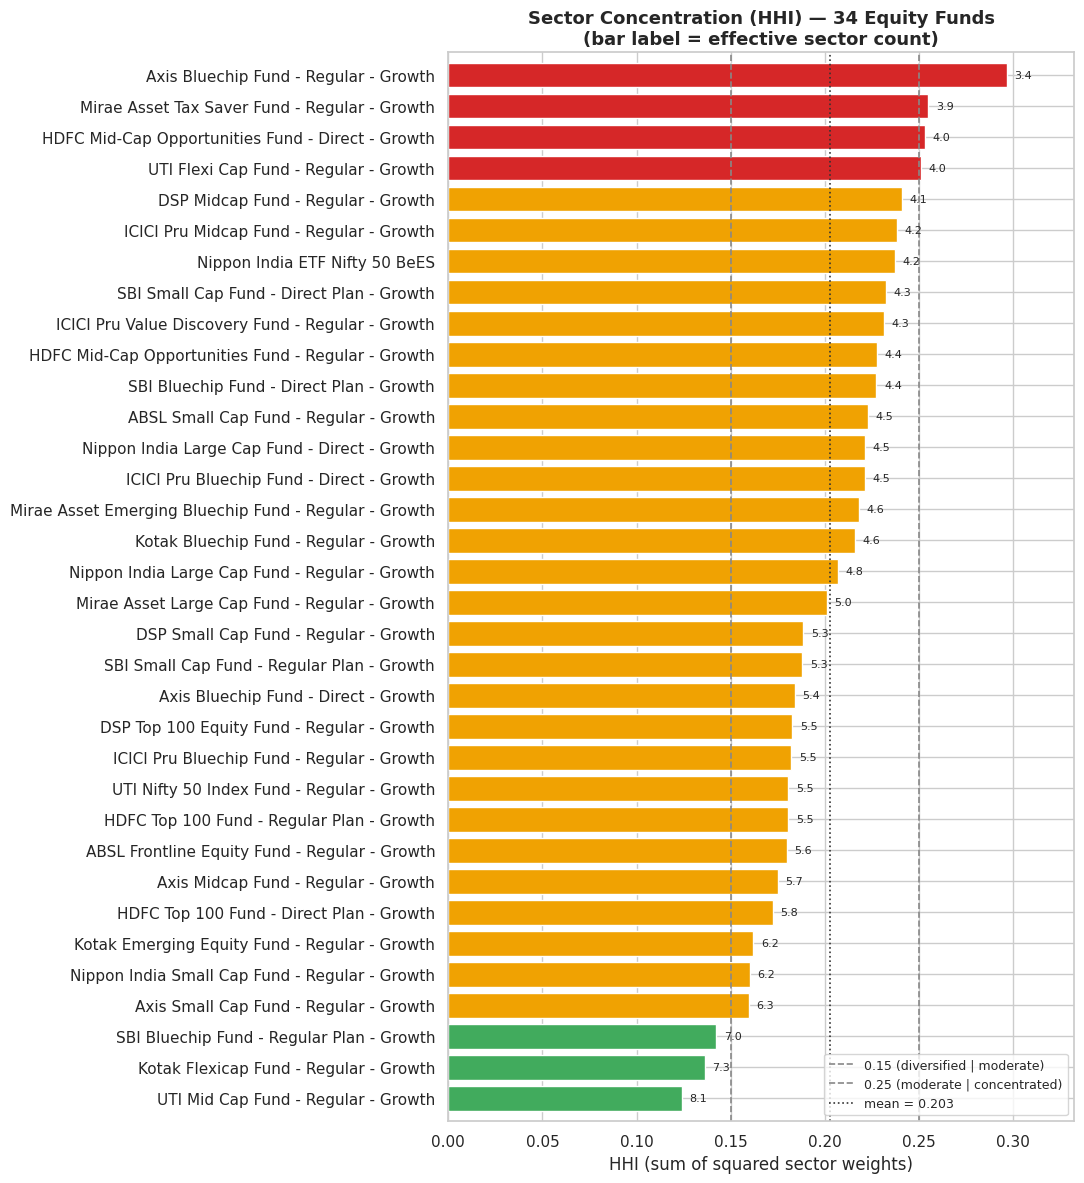

In [38]:
plot_df = sector_hhi.sort_values("hhi", ascending=True)   # most concentrated ends at top of barh

def tier_color(h):
    if h >= 0.25: return "#d62728"      # concentrated
    if h >= 0.15: return "#f0a202"      # moderate
    return "#41ab5d"                     # diversified

colors = plot_df["hhi"].map(tier_color)
mean_hhi = sector_hhi["hhi"].mean()

fig, ax = plt.subplots(figsize=(11, 12))
bars = ax.barh(plot_df["scheme_name"], plot_df["hhi"], color=colors)
for bar, eff in zip(bars, plot_df["effective_sectors"]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{eff:.1f}", va="center", ha="left", fontsize=8)

for x, lbl, ls in [(0.15, "0.15 (diversified | moderate)", "--"),
                   (0.25, "0.25 (moderate | concentrated)", "--"),
                   (mean_hhi, f"mean = {mean_hhi:.3f}", ":")]:
    ax.axvline(x, color="#333333" if ls == ":" else "#888888", linewidth=1.2, linestyle=ls, label=lbl)

ax.set_title("Sector Concentration (HHI) — 34 Equity Funds\n(bar label = effective sector count)",
             fontsize=13, weight="bold")
ax.set_xlabel("HHI (sum of squared sector weights)")
ax.margins(x=0.12, y=0.01)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

HHI_CHART_PATH = CHARTS_DIR / "sector_concentration.png"
fig.savefig(HHI_CHART_PATH, dpi=150, bbox_inches="tight")
print(f"Saved chart -> {HHI_CHART_PATH}")
plt.show()

### 6.7 Insights

*All figures are the actual values computed above — 34 equity funds, sector weights from the
**2025-12-31** holdings snapshot. HHI uses normalised decimal sector weights; effective_sectors = 1/HHI.*

**Most concentrated fund — Axis Bluechip.** HHI **0.297**, just **3.37 effective sectors**. Despite
nominally holding several sectors, it is effectively a ~3-sector bet: **IT alone is 48.7%** of the
portfolio, with FMCG (15.9%) and Banking (14.1%) next. Nearly half the fund rides on a single sector's
fortunes — the textbook definition of concentration risk, and notable for a "bluechip" fund usually
marketed as a steady core holding.

**Most diversified fund — UTI Mid Cap.** HHI **0.124**, **8.06 effective sectors** — it spreads across
**10 sectors** with no single one above **19.0%** (Consumer Goods 19.0%, Automobile 14.1%, Utilities
13.7%). It is the only fund whose largest sector stays under a fifth of the book, and the single name
that comfortably clears the "diversified" threshold.

**The universe sits in "moderate" territory.** The **average HHI is 0.203**, i.e. an average of **~5.1
effective sectors** — most funds behave like a 5-sector portfolio. By the DOJ-style cut-offs the split
is: **4 concentrated (HHI ≥ 0.25)**, **27 moderate (0.15–0.25)**, and just **3 diversified (< 0.15)**.
So genuine sector diversification is the *exception*, not the rule — concentration risk is the
background condition for this equity line-up.

**Category pattern — concentration isn't where you'd guess.** Sorting by sub-category mean HHI, the most
concentrated are the *single-strategy* funds — **ELSS (0.255)**, the **Index/ETF (0.238)** and **Value
(0.231)** — while the broad core categories cluster tightly: **Large Cap 0.201, Mid Cap 0.203, Flexi Cap
0.194, Small Cap 0.192**. Counter-intuitively, **small-caps are marginally *less* sector-concentrated
than large-caps** here — they scatter across more niche sectors, whereas some large-cap funds pile into
IT/Banking. (The single-fund sub-categories are noisy with n=1, so read those as individual funds, not
trends.)

**Diversification implications.**
- **HHI exposes risk that the fund label hides.** "Bluechip"/"large-cap" does not mean diversified —
  Axis Bluechip (3.4 effective sectors) carries more sector risk than several small-cap funds. An
  investor screening on category alone would miss this; HHI makes it explicit.
- **Use effective_sectors for sizing, not the sector count.** A fund listing 8 sectors but with 49% in
  one is really a ~3-sector exposure. Effective_sectors is the honest input to "how many independent
  bets am I actually making?" — and to spotting overlap when combining funds (two IT-heavy "diversified"
  funds don't add diversification).
- **Concentration is a double-edged sword, not a defect.** A high-HHI fund that is right on its dominant
  sector will outperform; the metric flags *fragility*, not *badness*. It should sit alongside the
  return/Sharpe/drawdown views from earlier sections — e.g. pairing a concentrated high-conviction fund
  with a genuinely diversified one (like UTI Mid Cap) to dilute single-sector exposure.

**Data note.** HHI is computed on the **disclosed holdings** (8–12 stocks per fund, summing to ~100%),
treated as the full portfolio per the data. Because a fund can only be as diversified as the number of
sectors it holds (6–10 here), the minimum achievable HHI is bounded by that count — funds touching fewer
sectors are *structurally* unable to score as diversified. The snapshot is a single date (2025-12-31);
sector tilts rotate over time, so this is a point-in-time concentration read, not a permanent trait.

## 7. Advanced Analytics Executive Summary

**Audience:** portfolio managers · mutual-fund analysts · business stakeholders
**Scope:** the six advanced analyses in this notebook, covering **40 schemes** (NAV returns 2022-01-03 →
2026-05-29), **5,000 investors / 32,778 transactions** (2024-01-01 → 2025-05-30), and the **2025-12-31**
holdings snapshot for the 34 equity funds.

*Every figure below is reproduced from the validated outputs of Sections 1–6 — no new calculation is
introduced here. Each section's table was exported to `data/processed/` and each chart to
`reports/charts/`.*

---

### Key Risk Findings

- **Tail risk spans ~90× across the line-up.** Daily 95% CVaR (expected shortfall) runs from **−3.03%**
  for the riskiest fund — **ABSL Small Cap** (VaR −2.39%) — to just **−0.03%** for the safest, **ICICI
  Pru Liquid** (VaR −0.02%). The **10 riskiest funds are all small- and mid-cap equity**; on average,
  losses that breach VaR overshoot it by ~34% (CVaR ≈ 1.34× VaR), so a VaR-only view understates the bad
  days. *(Section 1)*
- **Risk-adjusted performance is unstable through time for equity, stable for cash.** On a rolling
  90-day Sharpe, **SBI Small Cap is the most volatile series (σ = 1.68)** and crosses below zero ~29% of
  the time, while **UTI Nifty 50 Index is the most consistent market fund (σ = 1.11)**. ICICI Pru
  Liquid's average rolling Sharpe of **10.40** is a tiny-denominator artefact, **not** 10× the
  risk-adjusted return of equities — it must not be compared at face value. *(Section 2)*
- **Concentration is a hidden risk even in "safe-sounding" funds.** The average equity fund behaves like
  only **~5.1 independent sector bets** (mean HHI 0.203); the most concentrated, **Axis Bluechip**, is
  effectively a **3.4-sector** portfolio with **48.7% in IT alone**. *(Section 6)*

### Investor Behaviour Findings

- **The book is overwhelmingly equity-led and consistent in ticket size.** Both joining cohorts commit a
  near-identical **~₹81.9k (2024) vs ~₹81.5k (2025)** average inflow and allocate **~85% / ~83%** of
  transactions to equity. Ticket size looks like a product/default parameter, not a function of when an
  investor joined. *(Section 3)*
- **SIP regularity is weak under a monthly standard.** Of **1,362** investors with ≥ 6 SIPs, only **30
  (2.2%) are "Healthy"** (avg gap ≤ 35 days) while **1,332 (97.8%) are "At Risk."** The mean gap is
  **64.9 days** — roughly **bi-monthly** — and the longest single lapse is **372 days**. This is partly a
  threshold-vs-cadence mismatch (see Limitations), but the long-tail lapses are genuine. *(Section 4)*

### Fund Selection Findings

- **Large-caps win on risk-adjusted terms.** The single best Sharpe in the recommendable universe is
  **Mirae Asset Large Cap (1.068)** — it tops the Moderate bucket and beats every High-risk pick,
  confirming that large-caps delivered most of the return with far less volatility than small/mid-caps.
  The High-risk top-3 are **all mid-cap** (ICICI Pru Midcap 0.883, DSP Midcap 0.833, HDFC Mid-Cap
  0.808); **no small-cap qualified**, consistent with their deep tail risk and unstable rolling Sharpe.
  *(Sections 5, 1, 2)*
- **The engine is transparent and reusable** — rule-based (bucket by risk → rank by Sharpe → top 3),
  exported to `fund_recommendations.csv` and served by `src/recommender.py` — but it has real blind spots
  in the Low-risk bucket (see Limitations). *(Section 5)*

### Diversification Findings

- **Genuine sector diversification is the exception.** Across 34 equity funds: **4 concentrated**
  (HHI ≥ 0.25), **27 moderate**, and only **3 diversified** (HHI < 0.15). The standout is **UTI Mid Cap
  (HHI 0.124, 8.06 effective sectors)** — the only fund whose largest sector stays under a fifth of the
  book. *(Section 6)*
- **Fund labels hide concentration.** "Bluechip"/"large-cap" does not imply diversification: Axis
  Bluechip (3.4 effective sectors) carries more sector risk than several small-cap funds. **Effective
  sector count**, not the nominal sector list, is the honest input for position sizing and for spotting
  overlap when combining funds. *(Section 6)*

### Data Limitations

These caveats are material and should travel with any decision made on this analysis:

- **Synthetic benchmark (carried from Day 4).** Benchmark-relative metrics (alpha, beta, tracking error)
  rely on benchmark index series that are synthetic/modelled rather than live vendor data. Treat those
  relative figures as directional, and note the **risk-free rate assumption (6.5%)** flows into every
  Sharpe number used in Sections 2 and 5.
- **SIP cadence mismatch.** The "Healthy ≤ 35-day" rule assumes **monthly** SIPs, but the data's actual
  cadence is **~65 days (bi-monthly)**. That is why 97.8% land in "At Risk" — the result flags a
  **definition mismatch as much as a behaviour problem**, and the threshold should be recalibrated to the
  platform's true intended cadence before acting on it.
- **Cohort-window limitations.** Transactions span only **2024-01 → 2025-05**, so the 2024 cohort is
  **left-censored** (every pre-existing investor is tagged 2024) and 2025 is **truncated** (~5 months).
  Cohort *sizes* (4,803 vs 197) therefore reflect the observation window, **not** customer acquisition —
  "investor growth" is not measurable from this data.
- **Recommendation-engine limitations.** It is **single-metric (Sharpe) and single-window**, ignores
  expense ratio, fund size and drawdown, and **breaks down in the Low-risk bucket**: with a 6.5%
  risk-free rate every low-risk fund posts a **negative Sharpe** (best is SBI Gilt at −0.743), so the
  *safest* funds rank *worst*. Four sub-categories (Value, Index/ETF, Large & Mid Cap, ELSS) are
  **unmapped** and can never be recommended. It is a shortlist generator, not financial advice.
- **Forward-filled / snapshot data.** Forward-filled NAV days can flatten returns and *understate* tail
  magnitudes (Sections 1–2); HHI uses a **single-date (2025-12-31)** holdings snapshot, so sector tilts
  that rotate over time are not captured. All metrics here are **backward-looking**.

---

### Overall Conclusion

This equity-heavy line-up is defined by a clear **risk-for-return trade**: small- and mid-cap funds
deliver the headline returns but own the deepest tail losses, the most unstable risk-adjusted
performance, and — together with a few concentrated large-caps — meaningful single-sector fragility,
whereas **large-cap and index funds are the risk-adjusted and diversification winners** (Mirae Large Cap
on Sharpe, UTI Mid Cap on diversification, UTI Nifty 50 on consistency). On the investor side, behaviour
is **stable in ticket size and equity preference** but shows **weak SIP regularity and unmeasurable
acquisition** within this window. The most valuable next step is therefore **less about new models and
more about better inputs** — live benchmark data, a correct SIP-cadence definition, a longer transaction
history, and a multi-factor recommendation score (e.g. the Day 4 scorecard) — which would convert these
directionally-sound findings into decision-grade ones.